In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv('final_food_delivery.csv')
df.head()


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Delivery_Rating_Filled,Age_Group,Delivery_Category,Revenue_Category,Profit_Category
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,...,5.0,4.4,Weekend,True,0.13,5.0,Young Adult,Slow,Medium,Low Profit
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,...,5.0,4.7,Weekday,True,0.48,5.0,Adult,Fast,High,High Profit
2,ORD000003,CUST1765,39.0,Male,Delhi,South,RES723,Restaurant_244,Arabian,2024-12-08,...,4.0,4.9,Weekend,True,0.08,4.0,Adult,Slow,Low,Low Profit
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,...,2.0,3.4,Weekday,False,0.04,2.0,Adult,Average,Medium,Low Profit
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,...,2.0,4.4,Weekend,False,0.12,2.0,Senior,Fast,Low,Low Profit


TASK 1 - TOP SPENDING CUSTOMER

In [ ]:
#KPI Block for Task 1
total_customers = df['Customer_ID'].nunique()

avg_customer_revenue = (
    df.groupby('Customer_ID')['Final_Amount']
      .sum()
      .mean()
)

max_customer_revenue = (
    df.groupby('Customer_ID')['Final_Amount']
      .sum()
      .max()
)

print("Total Customers:", total_customers)
print("Average Customer Revenue:", round(avg_customer_revenue,2))
print("Highest Customer Revenue:", max_customer_revenue)

Total Customers: 8999
Average Customer Revenue: 18901.49
Highest Customer Revenue: 51827.0


Data Set for Task 1

In [ ]:
top_customers = (
    df.groupby('Customer_ID')['Final_Amount']
      .sum()
      .reset_index()
      .sort_values(
          by='Final_Amount',
          ascending=False
      )
)

top_customers.head(10)

,Customer_ID,Final_Amount
4266,CUST5267,51827.0
606,CUST1606,51171.0
5705,CUST6706,47389.0
5251,CUST6252,45925.0
4533,CUST5534,45218.0
239,CUST1239,44983.0
5456,CUST6457,44401.0
3430,CUST4431,44335.0
968,CUST1968,44281.0
5292,CUST6293,44211.0


Visualization for Task 1

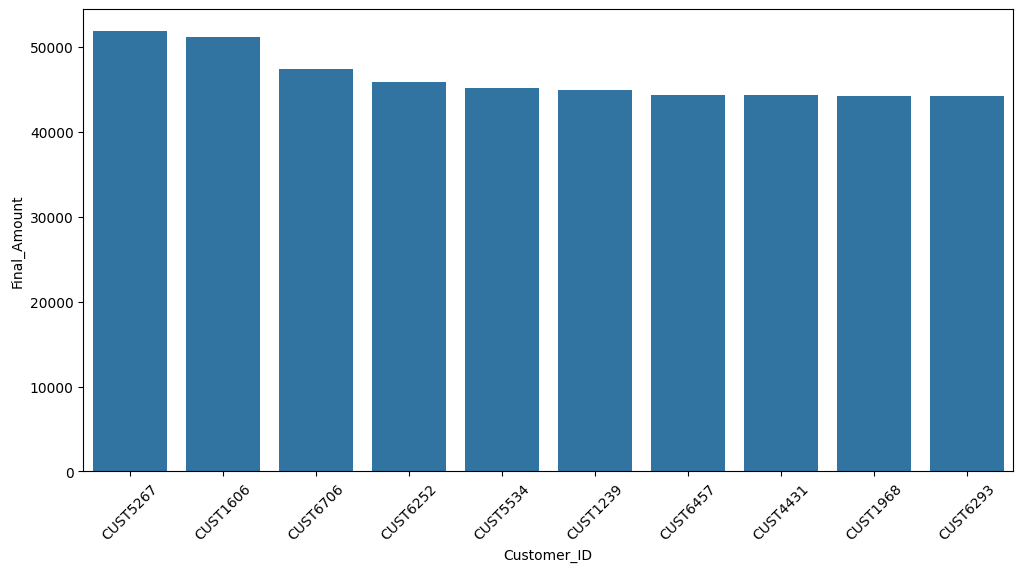

In [ ]:
top10 = top_customers.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10,
    x='Customer_ID',
    y='Final_Amount'
)
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Visualization 2 by
#Revenue Distribution

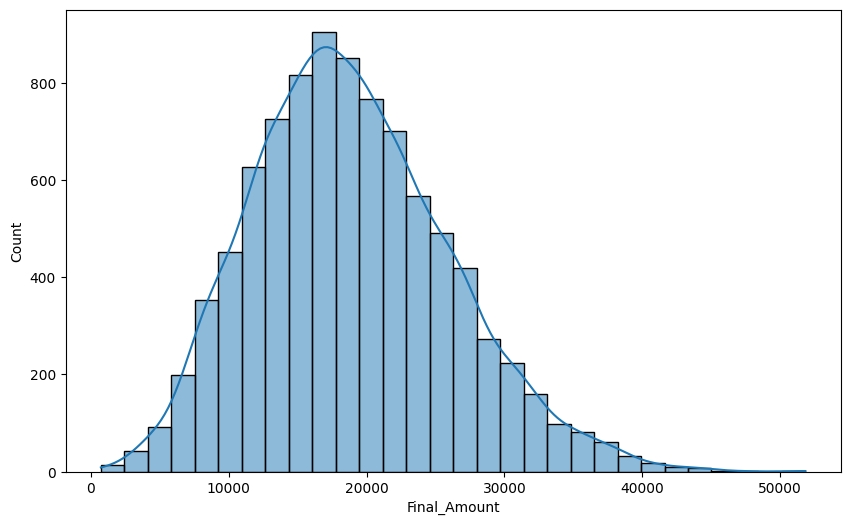

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(
    top_customers['Final_Amount'],
    bins=30,
    kde=True
)
plt.show()

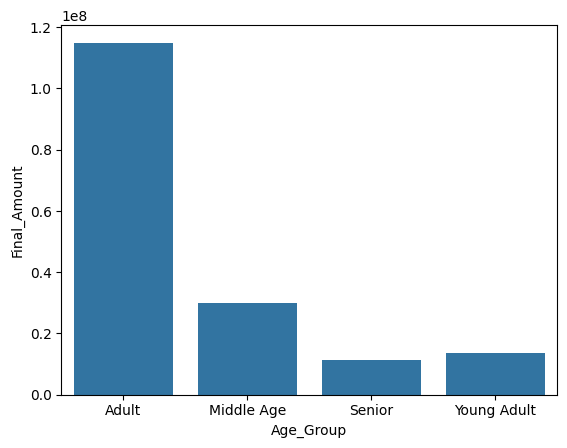

In [ ]:
#Visualization 3 by
#Age Group Contribution
age_revenue = (
    df.groupby('Age_Group')['Final_Amount']
      .sum()
      .reset_index()
)

sns.barplot(
    data=age_revenue,
    x='Age_Group',
    y='Final_Amount'
)
plt.show()

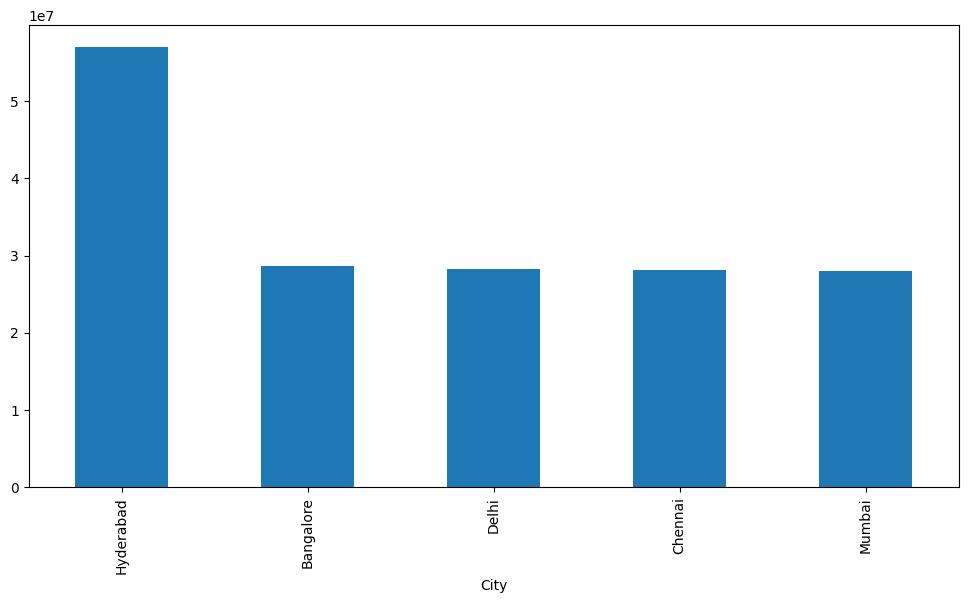

In [ ]:
#Visualization 4 by
#City Contribution
city_revenue = (
    df.groupby('City')['Final_Amount']
      .sum()
      .sort_values(
          ascending=False
      )
      .head(10)
)

city_revenue.plot(
    kind='bar',
    figsize=(12,6)
)
plt.show()

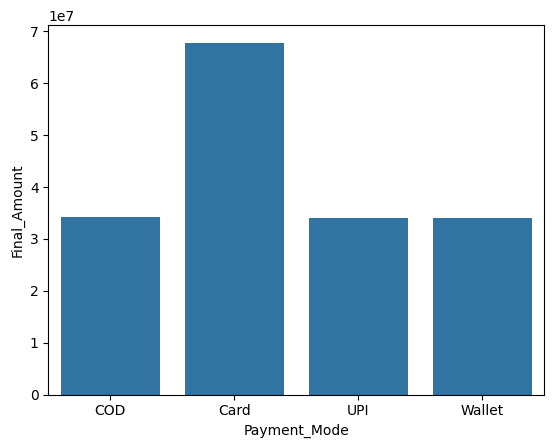

In [ ]:
#Visualization 5 by
#Payment Mode of High-Spending Customers
payment_revenue = (
    df.groupby('Payment_Mode')['Final_Amount']
      .sum()
      .reset_index()
)

sns.barplot(
    data=payment_revenue,
    x='Payment_Mode',
    y='Final_Amount'
)
plt.show()

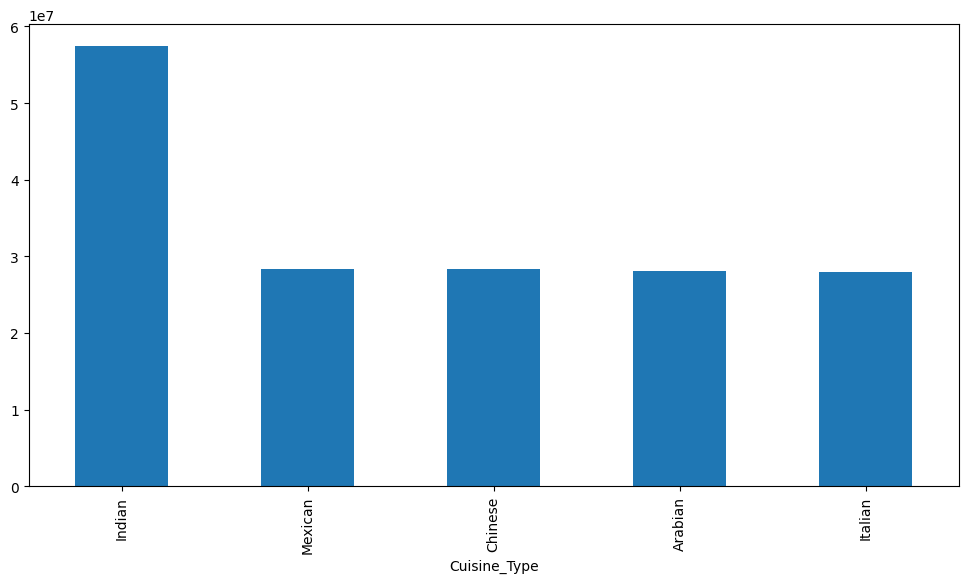

In [ ]:
#Visualization 6 by
#Cuisine Preference
cuisine_revenue = (
    df.groupby('Cuisine_Type')['Final_Amount']
      .sum()
      .sort_values(
          ascending=False
      )
)

cuisine_revenue.plot(
    kind='bar',
    figsize=(12,6)
)
plt.show()

Insights on Task 1

In [ ]:
#Insight Calculation 1
total_revenue = df['Final_Amount'].sum()

top10_revenue = top_customers.head(10)['Final_Amount'].sum()

Final = (top10_revenue / total_revenue) * 100

print("Top 10 Customers Spent {:.2f}% of the Total Revenue.".format(Final))

Top 10 Customers Spent 0.27% of the Total Revenue.


In [ ]:
#Insight Calculation 2
age_revenue.sort_values(
    by='Final_Amount',
    ascending=False
)



,Age_Group,Final_Amount
0,Adult,114948867.0
1,Middle Age,29912938.0
3,Young Adult,13765848.0
2,Senior,11466853.0


In [ ]:
#Insight Calculation 3
payment_revenue.sort_values(
    by='Final_Amount',
    ascending=False
)

,Payment_Mode,Final_Amount
1,Card,67783052.0
0,COD,34232164.0
3,Wallet,34056771.0
2,UPI,34022519.0


In [ ]:
#Insight Calculation 4
cuisine_revenue.head(10)

,Final_Amount
Cuisine_Type,
Indian,57427079.0
Mexican,28339695.0
Chinese,28327539.0
Arabian,28050563.0
Italian,27949630.0


Task 2: Age Group vs Order Value Analysis

In [ ]:
#KPI
age_summary = df.groupby('Age_Group').agg(
    Total_Revenue=('Final_Amount','sum'),
    Total_Orders=('Order_ID','count'),
    Avg_Order_Value=('Final_Amount','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).reset_index()

age_summary

,Age_Group,Total_Revenue,Total_Orders,Avg_Order_Value,Avg_Profit_Margin
0,Adult,114948867.0,67553,1701.610099,0.150735
1,Middle Age,29912938.0,17485,1710.777123,0.149713
2,Senior,11466853.0,6867,1669.848988,0.149055
3,Young Adult,13765848.0,8095,1700.537122,0.149758


Visualizations for Task -2

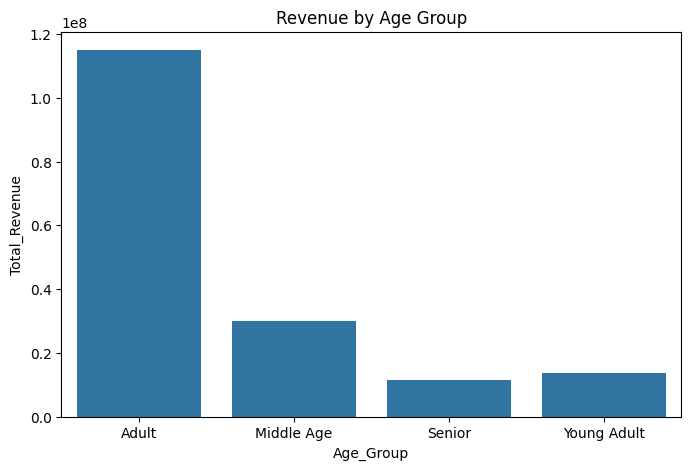

In [ ]:
#Visualization 1: Revenue by Age Group
plt.figure(figsize=(8,5))
sns.barplot(
    data=age_summary,
    x='Age_Group',
    y='Total_Revenue'
)
plt.title('Revenue by Age Group')
plt.show()

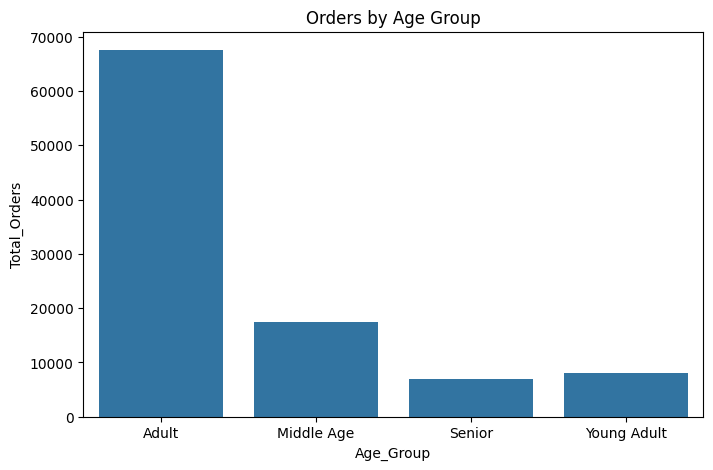

In [ ]:
#Visualization 2: Orders by Age Group
plt.figure(figsize=(8,5))
sns.barplot(
    data=age_summary,
    x='Age_Group',
    y='Total_Orders'
)
plt.title('Orders by Age Group')
plt.show()

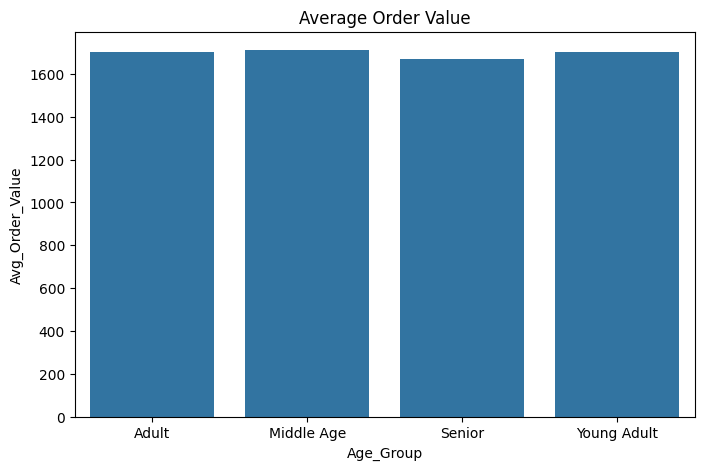

In [ ]:
#Visualization 3: Average Order Value
plt.figure(figsize=(8,5))
sns.barplot(
    data=age_summary,
    x='Age_Group',
    y='Avg_Order_Value'
)
plt.title('Average Order Value')
plt.show()

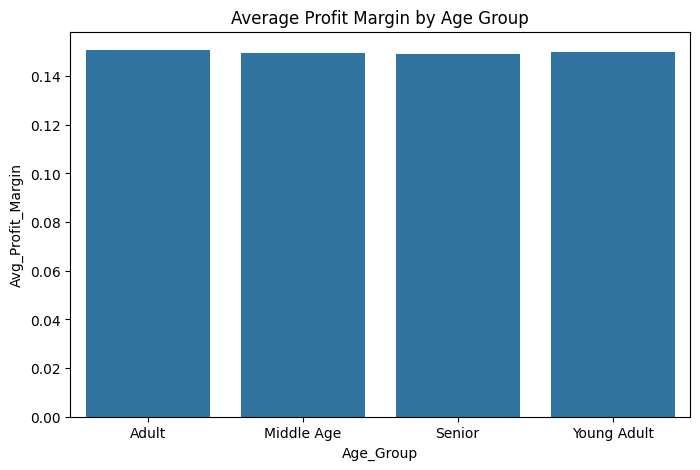

In [ ]:
#Visualization 4: Profit Margin by Age Group
plt.figure(figsize=(8,5))
sns.barplot(
    data=age_summary,
    x='Age_Group',
    y='Avg_Profit_Margin'
)
plt.title('Average Profit Margin by Age Group')
plt.show()

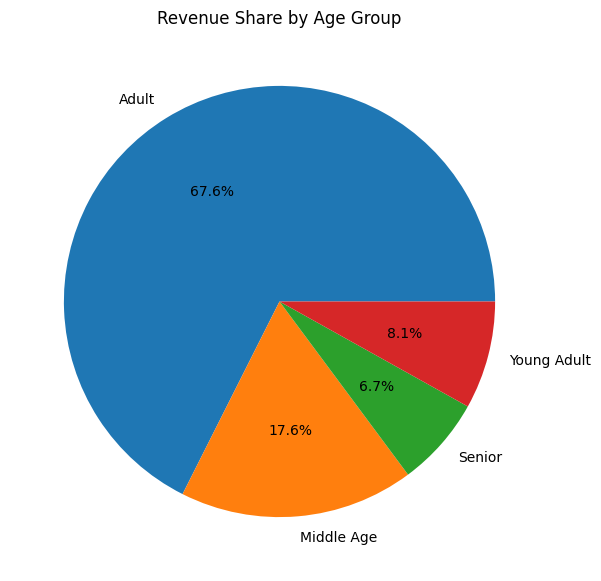

In [ ]:
#Visualization 5: Age Group Share
age_summary.set_index('Age_Group')['Total_Revenue'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)
plt.ylabel('')
plt.title('Revenue Share by Age Group')
plt.show()

Professional Insights
Insight 1

The Adult segment is the platform's primary customer base, generating ₹114.95 million in revenue and contributing approximately 67.7% of all orders.

Insight 2

Although Adults generate the highest revenue, the Middle Age segment has the highest average order value (₹1,710.78), indicating slightly higher spending per transaction.

Insight 3

Average order values are remarkably consistent across age groups (around ₹1,670–₹1,710), suggesting spending behavior is relatively stable regardless of age.

Insight 4

The Senior segment contributes the lowest revenue and order volume, indicating lower engagement compared to other demographic groups.

Task 3: Weekend vs Weekday Analysis

In [ ]:
df['Order_Day'].value_counts()

,count
Order_Day,
Weekday,71370
Weekend,28630


In [ ]:
#KPI for Task 3
week_summary = df.groupby('Order_Day').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Order_Value=('Final_Amount','mean'),
    Avg_Delivery_Time=('Delivery_Time_Min','mean'),
    Avg_Rating=('Delivery_Rating_Filled','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).reset_index()

week_summary

,Order_Day,Total_Orders,Total_Revenue,Avg_Order_Value,Avg_Delivery_Time,Avg_Rating,Avg_Profit_Margin
0,Weekday,71370,121578363.0,1703.493947,125.041950,2.995923,0.150487
1,Weekend,28630,48516143.0,1694.591093,124.832658,2.985470,0.150050


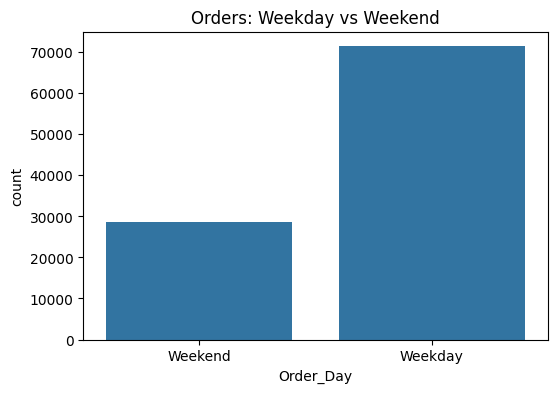

In [ ]:
#Visualization 1: Orders Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Order_Day')
plt.title('Orders: Weekday vs Weekend')
plt.show()

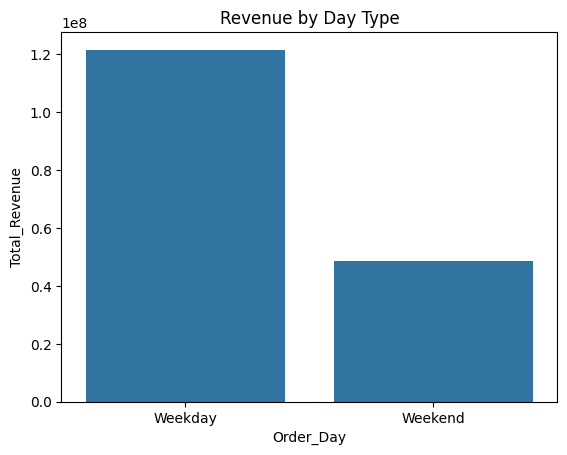

In [ ]:
#Visualization 2: Revenue Comparison
sns.barplot(
    data=week_summary,
    x='Order_Day',
    y='Total_Revenue'
)
plt.title('Revenue by Day Type')
plt.show()

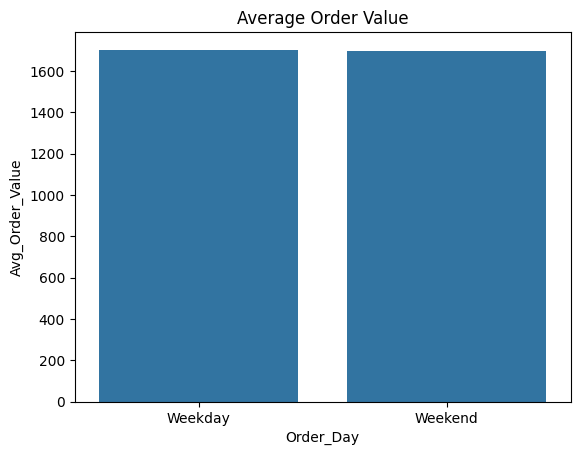

In [ ]:
#Visualization 3: Average Order Value
sns.barplot(
    data=week_summary,
    x='Order_Day',
    y='Avg_Order_Value'
)
plt.title('Average Order Value')
plt.show()

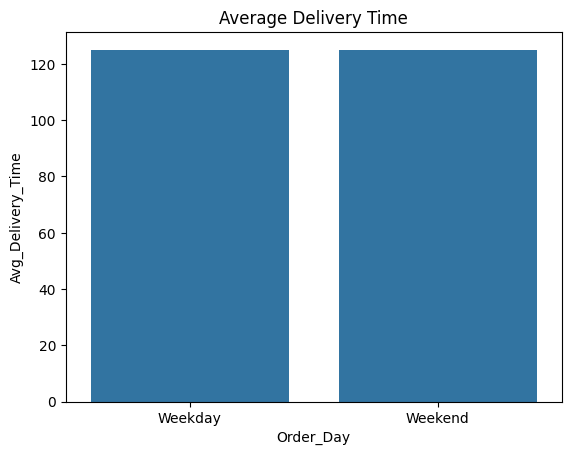

In [ ]:
#Visualization 4: Average Delivery Time
sns.barplot(
    data=week_summary,
    x='Order_Day',
    y='Avg_Delivery_Time'
)
plt.title('Average Delivery Time')
plt.show()

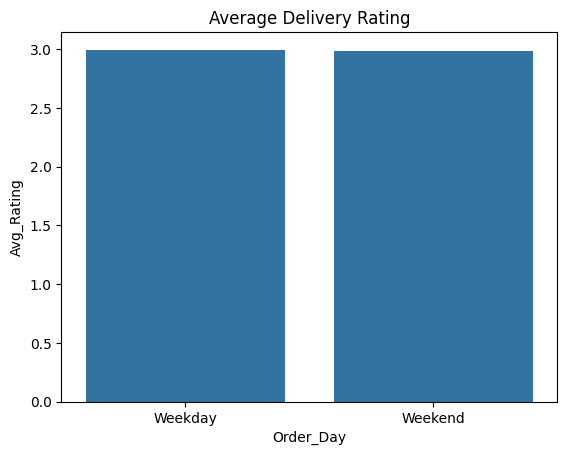

In [ ]:
#Visualization 5: Customer Ratings
sns.barplot(
    data=week_summary,
    x='Order_Day',
    y='Avg_Rating'
)
plt.title('Average Delivery Rating')
plt.show()

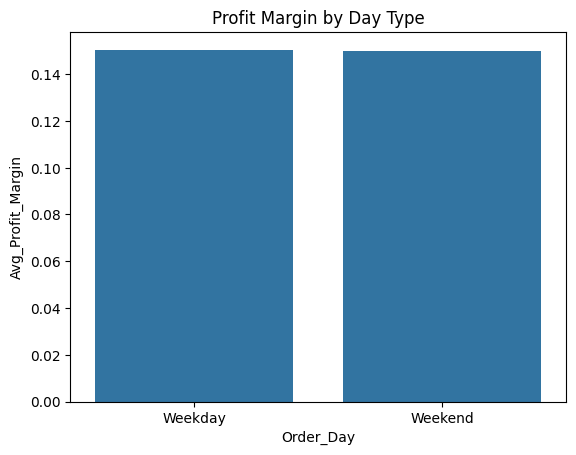

In [ ]:
#Visualization 6: Profit Margin
sns.barplot(
    data=week_summary,
    x='Order_Day',
    y='Avg_Profit_Margin'
)
plt.title('Profit Margin by Day Type')
plt.show()

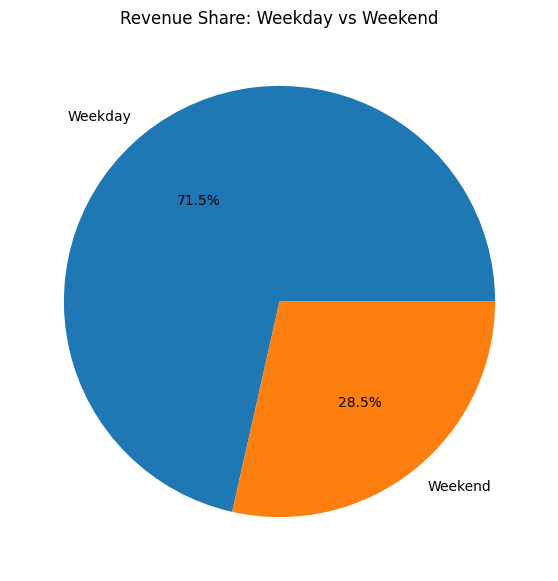

In [ ]:
revenue_share = df.groupby('Order_Day')['Final_Amount'].sum()

plt.figure(figsize=(7,7))
revenue_share.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title('Revenue Share: Weekday vs Weekend')
plt.show()

In [ ]:
weekday_share = 71370 / 100000 * 100
weekday_share

71.37

Professional Insights
Insight 1

71.37% of all orders occur on weekdays, indicating that customer demand is significantly higher during the workweek than weekends.

Insight 2

Average order values are nearly identical:

Weekday = ₹1703.49
Weekend = ₹1694.59

This suggests customers spend roughly the same amount regardless of day type.

Insight 3

Delivery performance remains remarkably consistent.

Weekday = 125.04 min
Weekend = 124.83 min

The platform appears capable of handling demand fluctuations without significantly impacting delivery times.

Insight 4

Profit margins remain stable across both periods.

Weekday = 15.05%
Weekend = 15.01%

This indicates operational efficiency is maintained throughout the week.

Task 4: Monthly Revenue Trends

In [17]:
# Convert to datetime
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

# Create date features
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()

In [18]:
df['Order_Date'].dtype

dtype('<M8[ns]')

In [19]:
print("Min Date:", df['Order_Date'].min())
print("Max Date:", df['Order_Date'].max())

Min Date: 2024-01-01 00:00:00
Max Date: 2024-12-30 00:00:00


In [20]:
monthly_summary = df.groupby('Month_Name').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Order_Value=('Final_Amount','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).reset_index()

In [21]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_summary['Month_Name'] = pd.Categorical(
    monthly_summary['Month_Name'],
    categories=month_order,
    ordered=True
)

monthly_summary = monthly_summary.sort_values('Month_Name')

monthly_summary

,Month_Name,Total_Orders,Total_Revenue,Avg_Order_Value,Avg_Profit_Margin
4,January,8508,14487752.0,1702.838740,0.149177
3,February,7921,13405376.0,1692.384295,0.149364
7,March,8417,14187318.0,1685.555186,0.150701
0,April,8115,13773642.0,1697.306470,0.150131
8,May,8350,14213329.0,1702.195090,0.149969
6,June,8180,13959821.0,1706.579584,0.151600
5,July,8513,14650673.0,1720.976507,0.149612
1,August,8261,14054729.0,1701.335068,0.148855
11,September,8183,14097100.0,1722.730050,0.153472
10,October,8306,14007992.0,1686.490730,0.148582


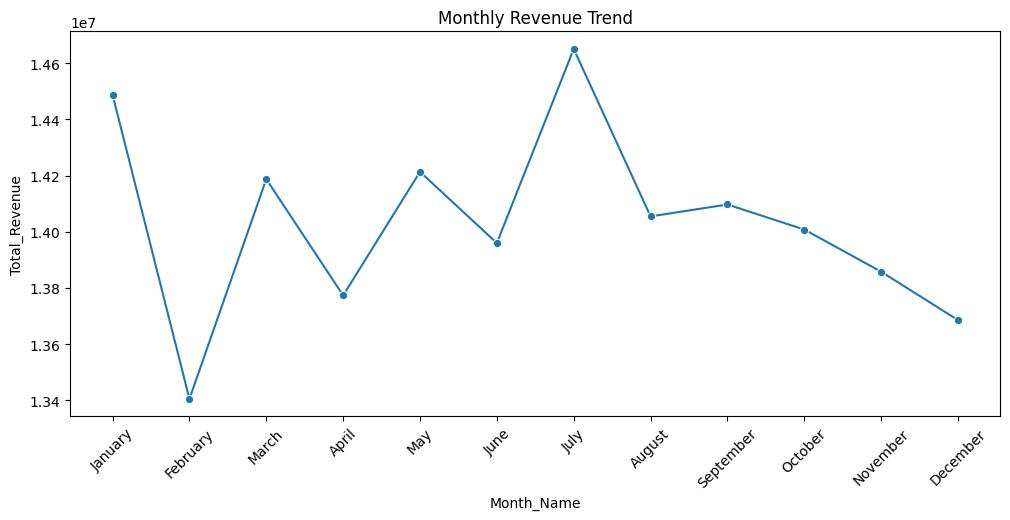

In [23]:
#Visualizations 1. Monthly Revenue Trend
plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_summary,
    x='Month_Name',
    y='Total_Revenue',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.show()

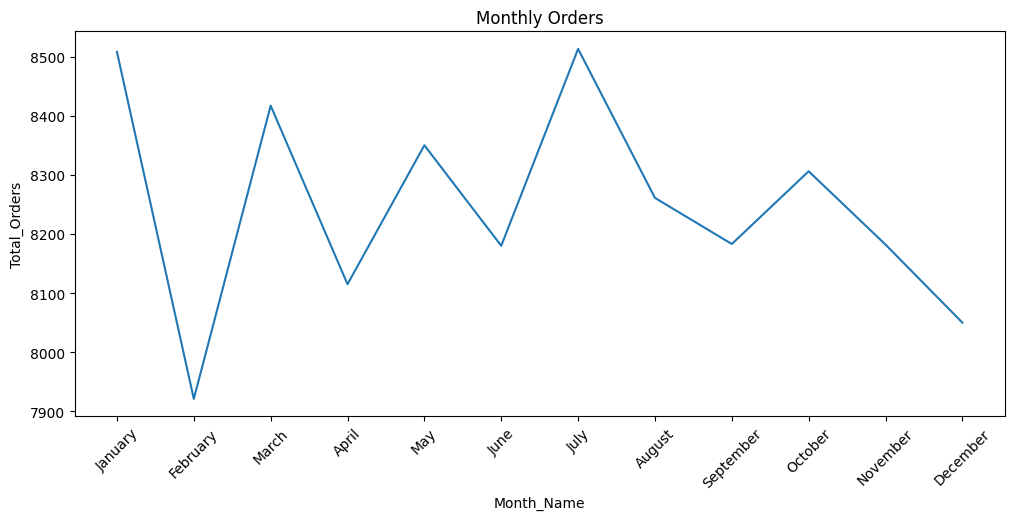

In [25]:
#Visualizations - 2. Monthly Orders
plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_summary,
    x='Month_Name',
    y='Total_Orders'
)

plt.xticks(rotation=45)
plt.title('Monthly Orders')
plt.show()

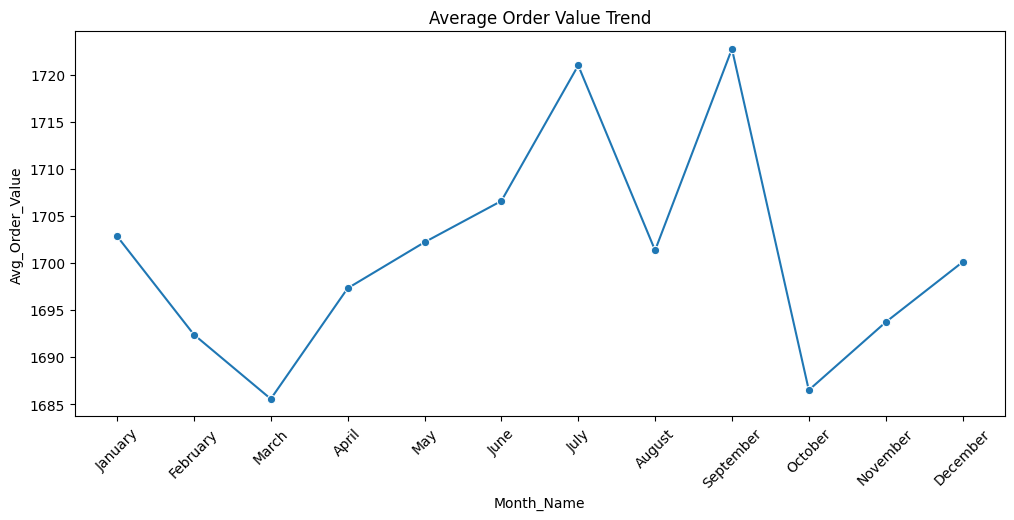

In [26]:
#3. Average Order Value
plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_summary,
    x='Month_Name',
    y='Avg_Order_Value',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Average Order Value Trend')
plt.show()

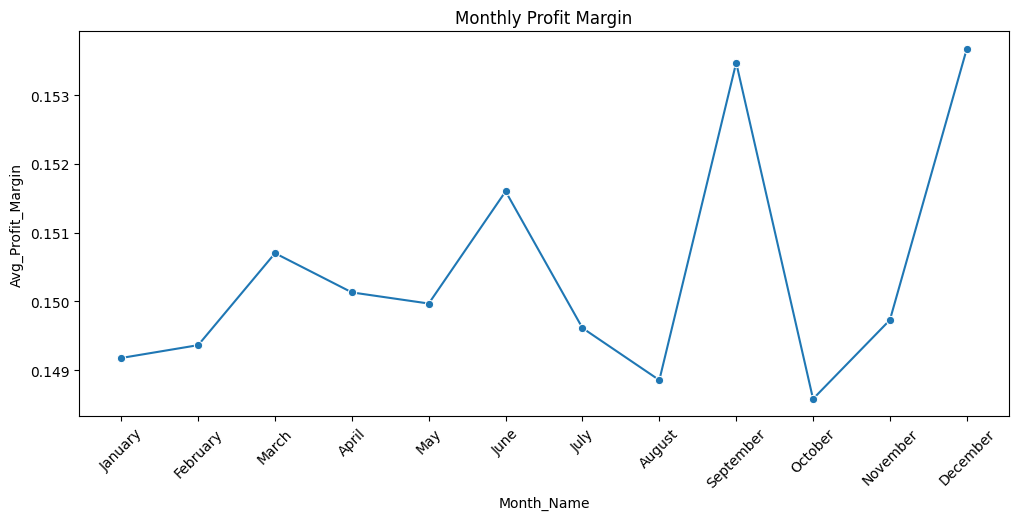

In [27]:
#4. Profit Margin Trend
plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_summary,
    x='Month_Name',
    y='Avg_Profit_Margin',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Monthly Profit Margin')
plt.show()

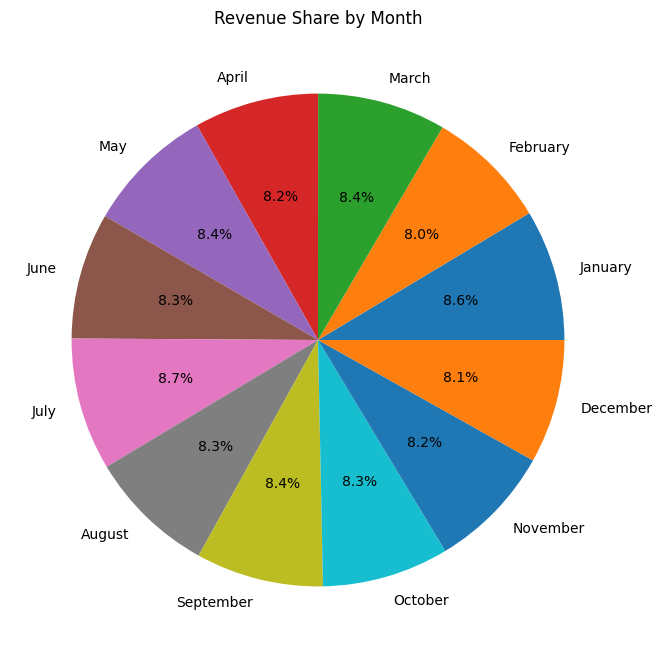

In [28]:
#5. Revenue Share by Month
monthly_summary.set_index('Month_Name')['Total_Revenue'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.ylabel('')
plt.title('Revenue Share by Month')
plt.show()

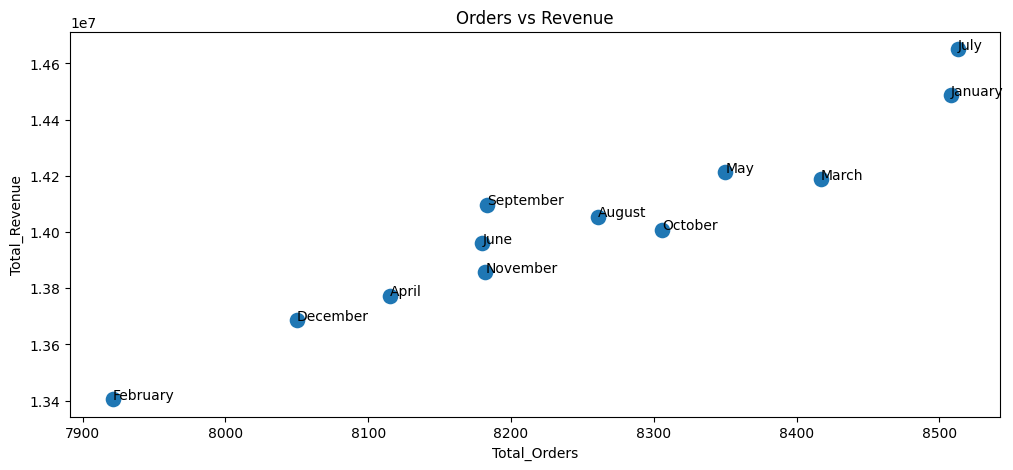

In [29]:
#6. Orders vs Revenue
plt.figure(figsize=(12,5))

sns.scatterplot(
    data=monthly_summary,
    x='Total_Orders',
    y='Total_Revenue',
    s=150
)

for i,row in monthly_summary.iterrows():
    plt.text(
        row['Total_Orders'],
        row['Total_Revenue'],
        row['Month_Name']
    )

plt.title('Orders vs Revenue')
plt.show()

In [31]:
monthly_summary['Revenue_Growth_%'] = (
    monthly_summary['Total_Revenue']
    .pct_change() * 100
)

monthly_summary[['Month_Name','Revenue_Growth_%']].sort_values(
    by='Revenue_Growth_%',
    ascending=False
)

,Month_Name,Revenue_Growth_%
7,March,5.833048
5,July,4.948860
8,May,3.192235
11,September,0.301471
10,October,-0.632102
9,November,-1.071603
2,December,-1.242528
6,June,-1.783593
0,April,-2.915815
1,August,-4.067690


Professional Insights
Insight 1

July generated the highest revenue (₹14.65 million) and also recorded the highest order volume (8,513 orders), indicating a strong positive relationship between order count and revenue.

Insight 2

February produced the lowest revenue (₹13.41 million) and the lowest order volume (7,921 orders), making it the weakest performing month.

Insight 3

September recorded one of the highest average order values (₹1,722.73) despite not having the highest order count, indicating customers placed larger-value orders during this period.

Insight 4

Profit margins remained highly stable throughout the year (14.8%–15.4%), suggesting consistent pricing and operational efficiency.

Task 5: Impact of Discounts on Profit.

In [32]:
discount_summary = df.groupby('Discount_Applied').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Profit_Margin=('Profit_Margin','mean'),
    Avg_Order_Value=('Order_Value','mean')
).reset_index()

discount_summary.sort_values('Discount_Applied')

,Discount_Applied,Total_Orders,Total_Revenue,Avg_Profit_Margin,Avg_Order_Value
0,0.0,16650,29633046.0,0.150655,1779.762523
1,20.0,16569,29113166.0,0.149466,1777.086487
2,50.0,33405,58306269.0,0.149026,1795.435384
3,100.0,16776,28280062.0,0.151326,1785.745231
4,300.0,16600,24761963.0,0.152678,1788.102771


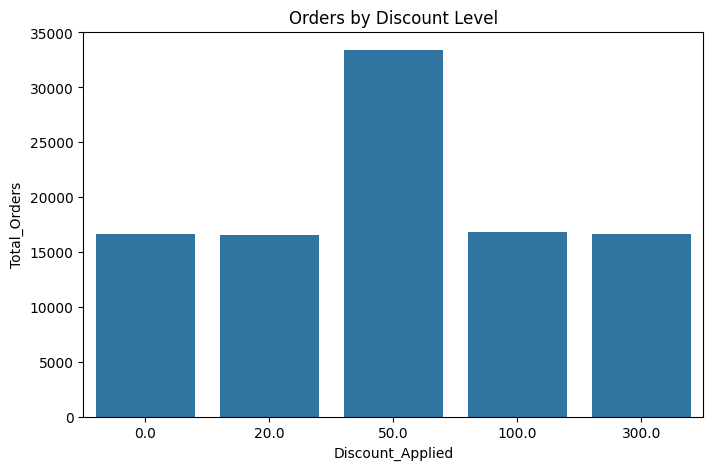

In [33]:
#Visualization 1: Orders by Discount
plt.figure(figsize=(8,5))
sns.barplot(
    data=discount_summary,
    x='Discount_Applied',
    y='Total_Orders'
)
plt.title('Orders by Discount Level')
plt.show()

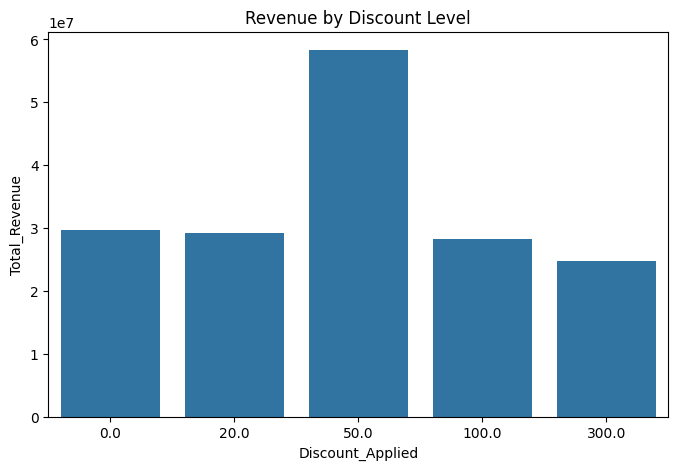

In [34]:
#Visualization 2: Revenue by Discount
plt.figure(figsize=(8,5))
sns.barplot(
    data=discount_summary,
    x='Discount_Applied',
    y='Total_Revenue'
)
plt.title('Revenue by Discount Level')
plt.show()

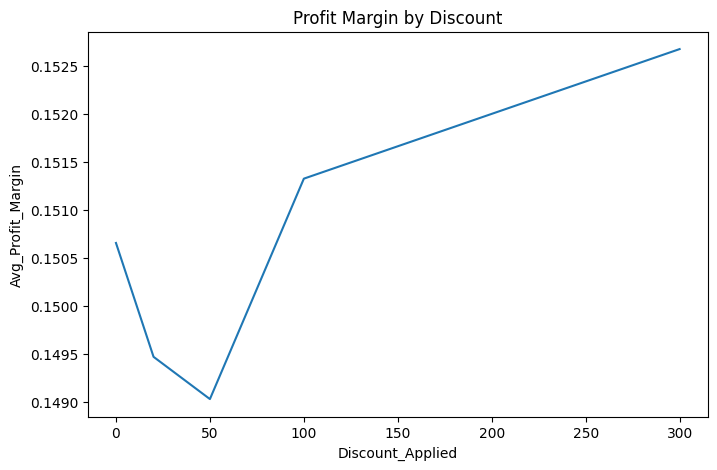

In [35]:
#Visualization 3: Profit Margin by Discount
plt.figure(figsize=(8,5))
sns.lineplot(
    data=discount_summary,
    x='Discount_Applied',
    y='Avg_Profit_Margin'
)
plt.title('Profit Margin by Discount')
plt.show()

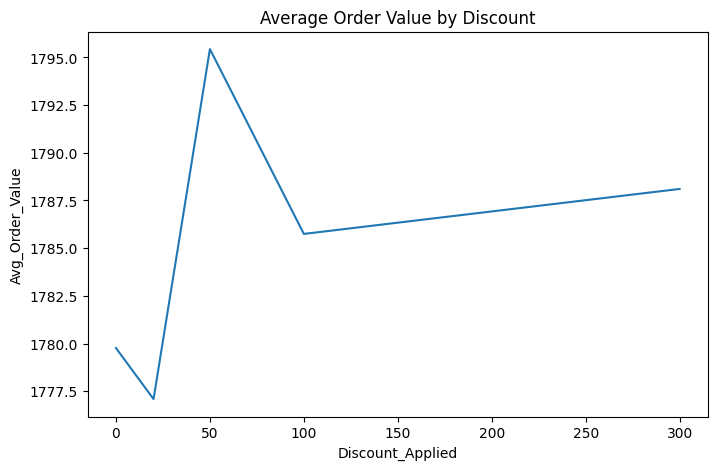

In [37]:
#Visualization 4: Average Order Value
plt.figure(figsize=(8,5))
sns.lineplot(
    data=discount_summary,
    x='Discount_Applied',
    y='Avg_Order_Value'
)
plt.title('Average Order Value by Discount')
plt.show()

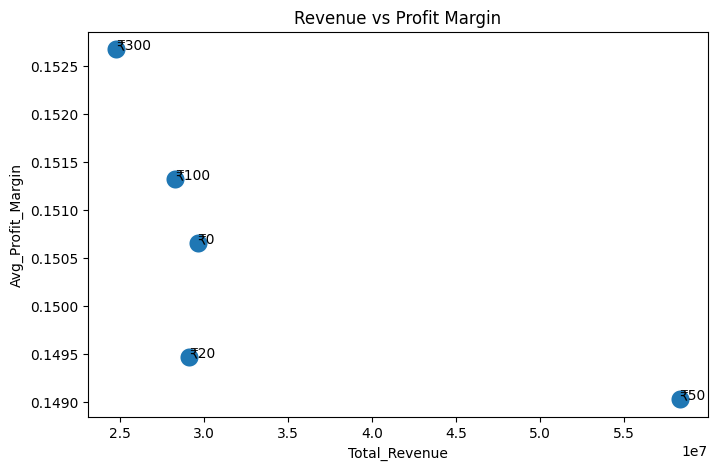

In [38]:
#Visualization 5: Revenue vs Profit Margin
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=discount_summary,
    x='Total_Revenue',
    y='Avg_Profit_Margin',
    s=200
)

for _, row in discount_summary.iterrows():
    plt.text(
        row['Total_Revenue'],
        row['Avg_Profit_Margin'],
        f"₹{int(row['Discount_Applied'])}"
    )

plt.title('Revenue vs Profit Margin')
plt.show()

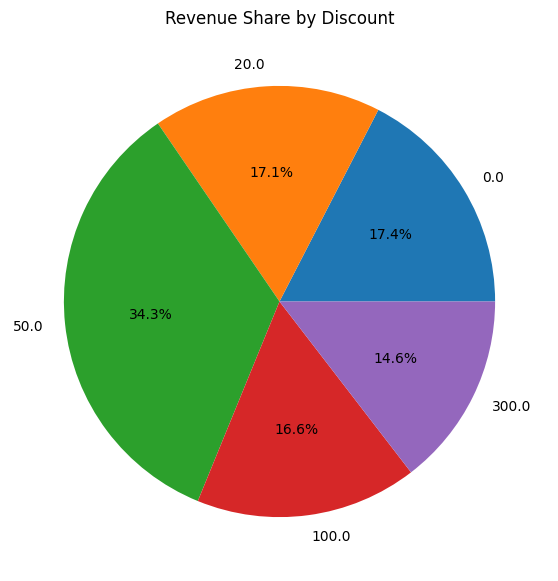

In [39]:
#Visualization 6: Revenue Share by Discount
discount_summary.set_index('Discount_Applied')['Total_Revenue'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.ylabel('')
plt.title('Revenue Share by Discount')
plt.show()

Professional Insights
Insight 1

The ₹50 discount level generated the highest number of orders (33,405) and the highest revenue (₹58.31 million), indicating that moderate discounts are highly effective at driving customer demand.

Insight 2

The ₹300 discount level generated the lowest revenue (₹24.76 million) despite having a similar number of orders to other discount categories, suggesting that aggressive discounting may reduce revenue realization.

Insight 3

Average order values remain remarkably stable across all discount levels (₹1777–₹1795), indicating discounts do not significantly influence basket size.

Insight 4

Interestingly, the ₹300 discount category shows the highest profit margin (15.27%) in this dataset, while the ₹50 discount category has the lowest (14.90%). This suggests profit margin is influenced by additional factors beyond discounts alone, such as restaurant mix, cuisine mix, or operational efficiencies.

Task 7 Delivery Time by City

In [53]:
delivery_city = df.groupby('City').agg(
    Avg_Delivery_Time=('Delivery_Time_Min','mean'),
    Avg_Delivery_Rating=('Delivery_Rating_Filled','mean'),
    Total_Orders=('Order_ID','count')
).reset_index()

delivery_city.sort_values(
    by='Avg_Delivery_Time',
    ascending=False
)

,City,Avg_Delivery_Time,Avg_Delivery_Rating,Total_Orders
4,Mumbai,125.937246,2.990602,16493
3,Hyderabad,125.070872,3.001547,33610
2,Delhi,124.896376,2.995987,16695
1,Chennai,124.549423,2.976381,16470
0,Bangalore,124.373297,2.991155,16732


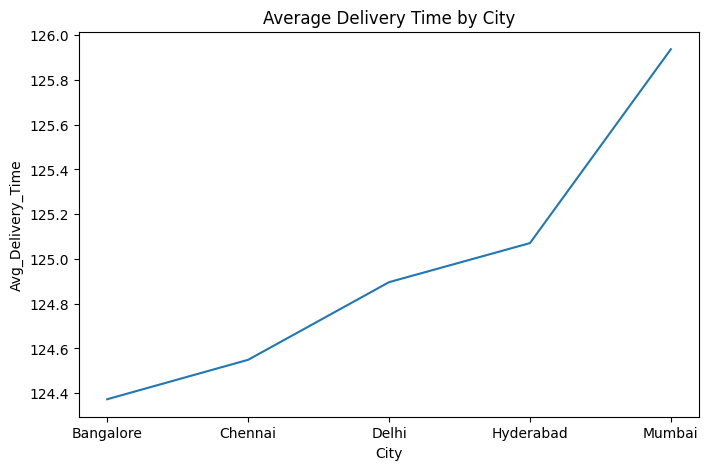

In [55]:
#Visualizations 1. Average Delivery Time by City
plt.figure(figsize=(8,5))
sns.lineplot(
    data=delivery_city,
    x='City',
    y='Avg_Delivery_Time'
)
plt.title('Average Delivery Time by City')
plt.show()

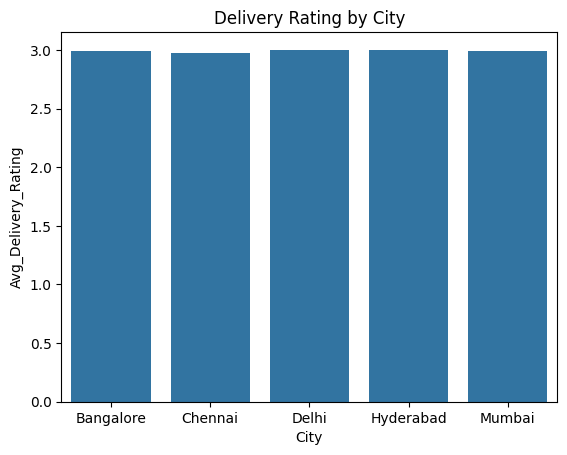

In [56]:
#2. Delivery Rating by City
sns.barplot(
    data=delivery_city,
    x='City',
    y='Avg_Delivery_Rating'
)
plt.title('Delivery Rating by City')
plt.show()

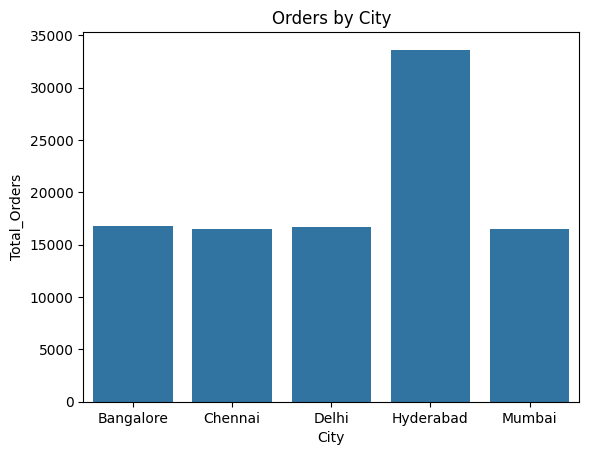

In [57]:
#3. Orders by City
sns.barplot(
    data=delivery_city,
    x='City',
    y='Total_Orders'
)
plt.title('Orders by City')
plt.show()

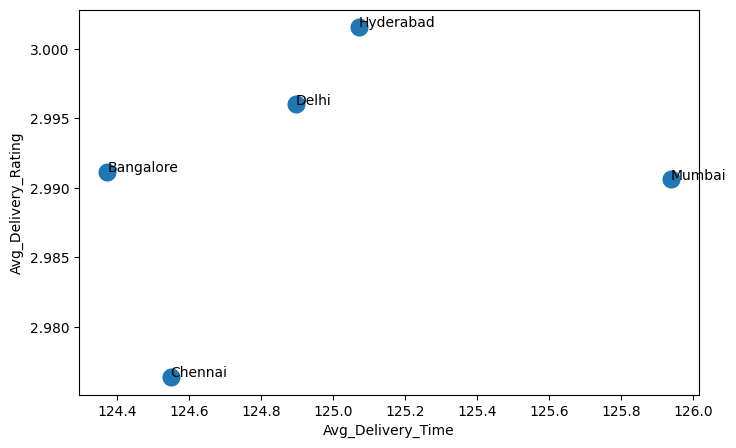

In [58]:
#4. Delivery Time vs Rating
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=delivery_city,
    x='Avg_Delivery_Time',
    y='Avg_Delivery_Rating',
    s=200
)

for _, row in delivery_city.iterrows():
    plt.text(
        row['Avg_Delivery_Time'],
        row['Avg_Delivery_Rating'],
        row['City']
    )

plt.show()

Professional Insights
Insight 1

Mumbai records the highest average delivery time (125.94 minutes), suggesting slightly greater logistical complexity compared to other cities.

Insight 2

Bangalore achieves the fastest average delivery time (124.37 minutes) while maintaining customer ratings comparable to other cities.

Insight 3

Hyderabad handles the highest order volume (33,610 orders) while maintaining delivery performance similar to other cities, indicating strong operational scalability.

Insight 4

Delivery ratings remain highly consistent across all cities (approximately 3.0), suggesting standardized customer experience.

Task 8 - Distance vs Delivery Delay

In [61]:
distance_summary = df.groupby(
    pd.cut(
        df['Distance_km'],
        bins=[0,5,10,20,30,40]
    )
).agg(
    Avg_Delivery_Time=('Delivery_Time_Min','mean'),
    Avg_Rating=('Delivery_Rating_Filled','mean'),
    Total_Orders=('Order_ID','count')
).reset_index()

distance_summary

/tmp/ipykernel_9742/3636174251.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_summary = df.groupby(


,Distance_km,Avg_Delivery_Time,Avg_Rating,Total_Orders
0,"(0, 5]",124.475197,2.995490,14857
1,"(5, 10]",124.923271,2.991366,52001
2,"(10, 20]",125.517755,2.992326,6646
3,"(20, 30]",125.475812,2.995425,13333
4,"(30, 40]",125.015574,2.993998,13163


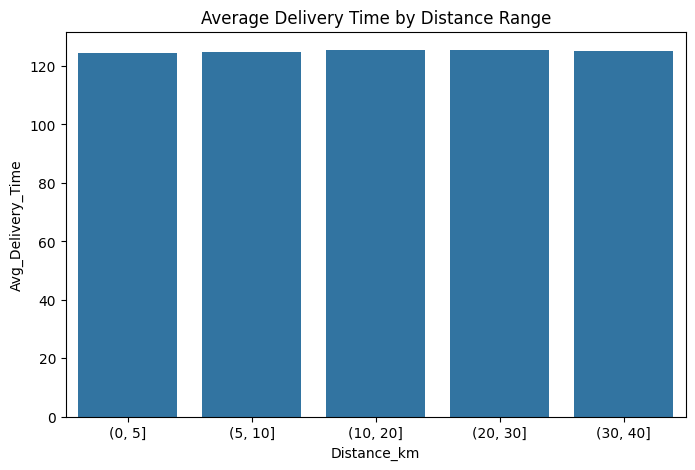

In [71]:
#Visualizations 1. Average Delivery Time by Distance Range
plt.figure(figsize=(8,5))
sns.barplot(
    data=distance_summary,
    x='Distance_km',
    y='Avg_Delivery_Time'
)
plt.title('Average Delivery Time by Distance Range')
plt.show()

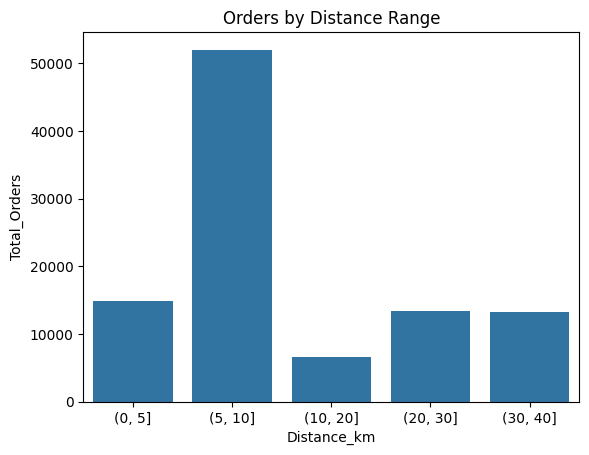

In [65]:
#2. Orders by Distance Range
sns.barplot(
    data=distance_summary,
    x='Distance_km',
    y='Total_Orders'
)
plt.title('Orders by Distance Range')
plt.show()

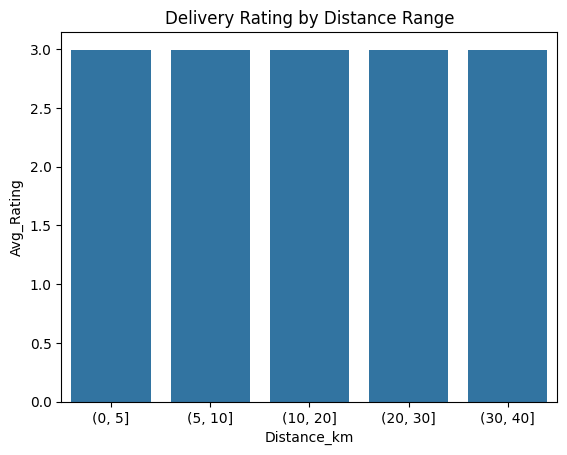

In [72]:
#3. Delivery Rating by Distance Range
sns.barplot(
    data=distance_summary,
    x='Distance_km',
    y='Avg_Rating'
)
plt.title('Delivery Rating by Distance Range')
plt.show()

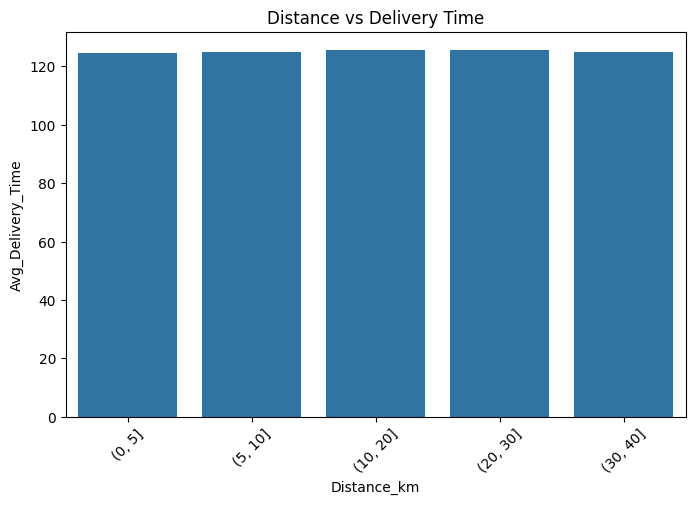

In [74]:
#4. Distance vs Delivery Time Trend
plt.figure(figsize=(8,5))

sns.barplot(
    data=distance_summary,
    x='Distance_km',
    y='Avg_Delivery_Time'
)

plt.title('Distance vs Delivery Time')
plt.xticks(rotation=45)
plt.show()

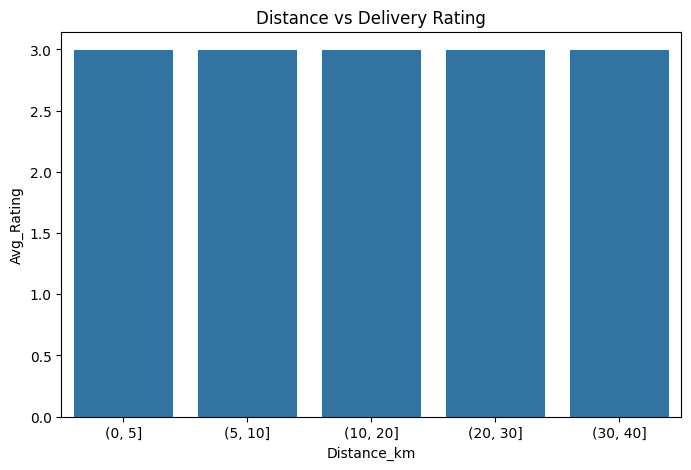

In [77]:
#5. Distance vs Rating
plt.figure(figsize=(8,5))
sns.barplot(
    data=distance_summary,
    x='Distance_km',
    y='Avg_Rating',

)
plt.title('Distance vs Delivery Rating')
plt.show()

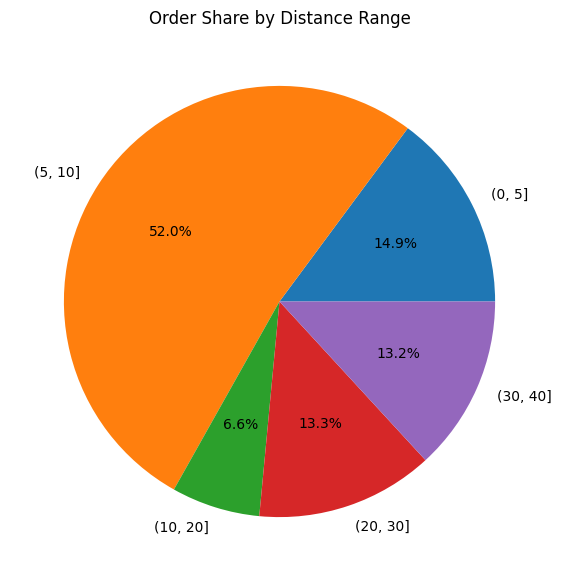

In [78]:
#6. Orders Share by Distance
distance_summary.set_index('Distance_km')['Total_Orders'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)
plt.ylabel('')
plt.title('Order Share by Distance Range')
plt.show()

Professional Insights
Insight 1

The 5–10 km range accounts for the majority of orders (52,001 orders), making it the platform's most common delivery distance.

Insight 2

Average delivery times remain highly consistent across all distance categories (124–126 minutes), indicating standardized delivery performance.

Insight 3

The longest average delivery time occurs in the 10–20 km range (125.52 minutes), but the difference is operationally small.

Insight 4

Customer ratings remain stable regardless of delivery distance, suggesting distance alone does not significantly affect customer satisfaction.

Task 9 → Delivery Rating vs Delivery Time

In [79]:
rating_time = df.groupby(
    pd.cut(
        df['Delivery_Time_Min'],
        bins=[0,60,120,180,240,300]
    )
).agg(
    Avg_Rating=('Delivery_Rating_Filled','mean'),
    Total_Orders=('Order_ID','count')
).reset_index()

rating_time

/tmp/ipykernel_9742/4182236969.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_time = df.groupby(


,Delivery_Time_Min,Avg_Rating,Total_Orders
0,"(0, 60]",2.995228,26613
1,"(60, 120]",2.987469,40141
2,"(120, 180]",2.988551,11180
3,"(180, 240]",3.003237,11123
4,"(240, 300]",3.001371,10943


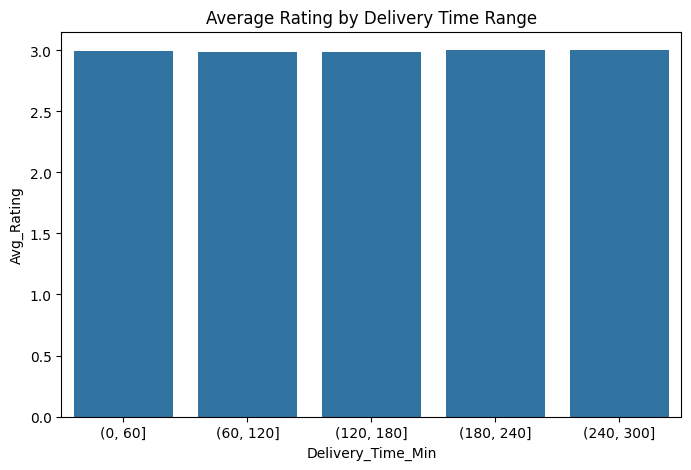

In [82]:
#Visualizations 1. Average Rating by Delivery Time
plt.figure(figsize=(8,5))

sns.barplot(
    data=rating_time,
    x='Delivery_Time_Min',
    y='Avg_Rating'
)

plt.title('Average Rating by Delivery Time Range')
plt.show()

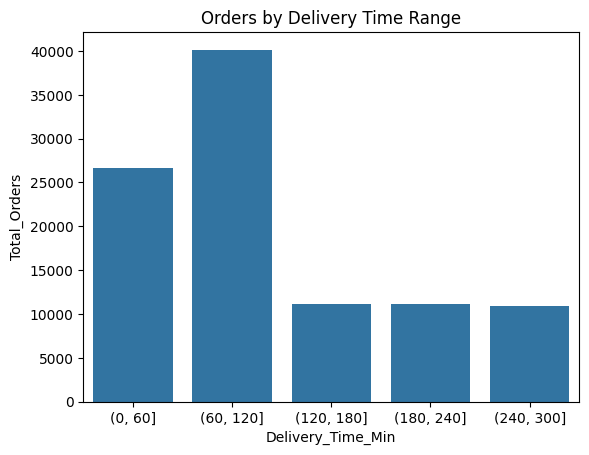

In [83]:
#2. Orders by Delivery Time Range
sns.barplot(
    data=rating_time,
    x='Delivery_Time_Min',
    y='Total_Orders'
)

plt.title('Orders by Delivery Time Range')
plt.show()

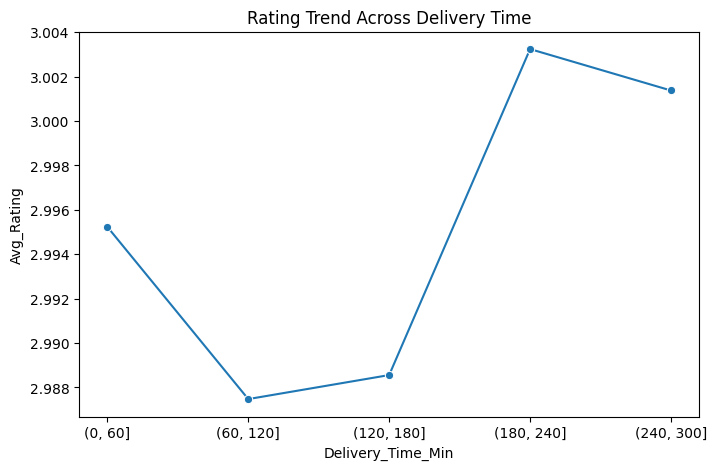

In [84]:
#3. Rating Trend
rating_time['Delivery_Time_Min'] = rating_time['Delivery_Time_Min'].astype(str)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=rating_time,
    x='Delivery_Time_Min',
    y='Avg_Rating',
    marker='o'
)

plt.title('Rating Trend Across Delivery Time')
plt.show()

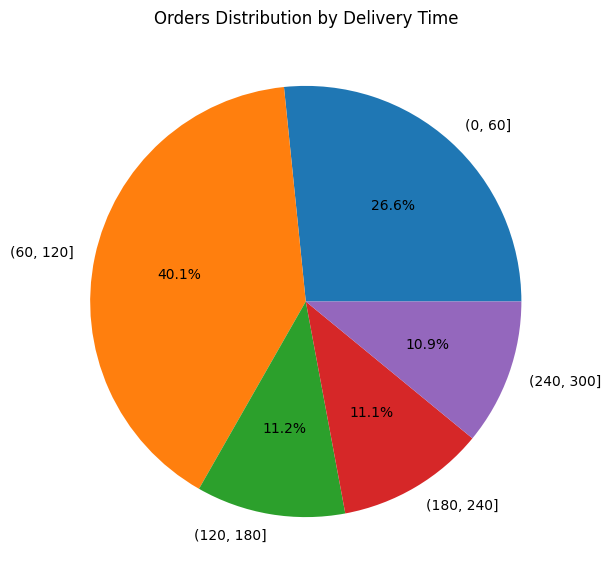

In [85]:
#4. Orders Distribution
rating_time.set_index('Delivery_Time_Min')['Total_Orders'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.ylabel('')
plt.title('Orders Distribution by Delivery Time')
plt.show()

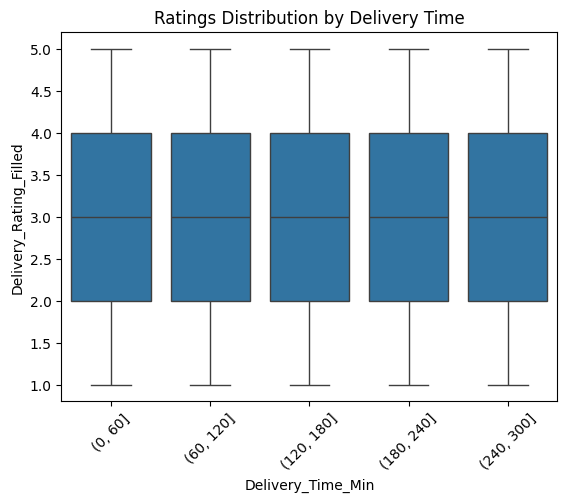

In [86]:
#5. Rating Distribution
sns.boxplot(
    data=df,
    x=pd.cut(df['Delivery_Time_Min'],
             bins=[0,60,120,180,240,300]),
    y='Delivery_Rating_Filled'
)

plt.xticks(rotation=45)
plt.title('Ratings Distribution by Delivery Time')
plt.show()

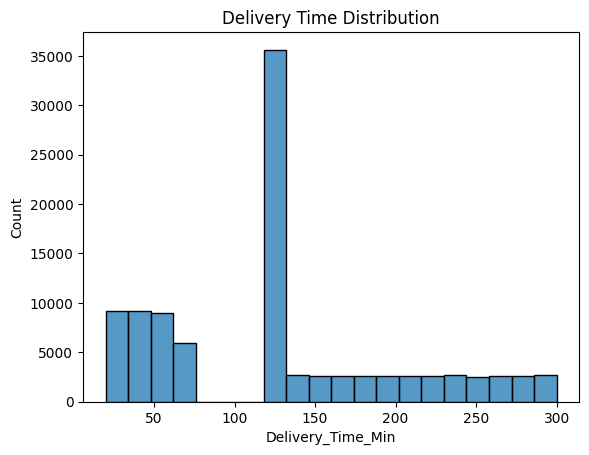

In [87]:
#6. Delivery Time Frequency
sns.histplot(
    df['Delivery_Time_Min'],
    bins=20
)

plt.title('Delivery Time Distribution')
plt.show()

Professional Insights
Insight 1

The 60–120 minute category contains the highest number of orders (40,141), making it the most common delivery duration.

Insight 2

Average ratings remain remarkably stable across all delivery-time categories, ranging only from 2.987 to 3.003.

Insight 3

Longer delivery times do not appear to significantly reduce customer ratings in this dataset.

Insight 4

The highest average rating is observed in the 180–240 minute range (3.003), indicating customer satisfaction is likely influenced by factors beyond delivery speed.

Task 10: Top Rated Restaurants

In [88]:
top_restaurants = df.groupby('Restaurant_Name').agg(
    Avg_Rating=('Restaurant_Rating','mean'),
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum')
).reset_index()

top_restaurants = top_restaurants[
    top_restaurants['Total_Orders'] >= 100
]

top_restaurants.sort_values(
    by='Avg_Rating',
    ascending=False
).head(10)

,Restaurant_Name,Avg_Rating,Total_Orders,Total_Revenue
3,Restaurant_101,4.325843,178,291340.0
0,Restaurant_1,4.313472,193,310986.0
70,Restaurant_162,4.308242,182,289881.0
440,Restaurant_496,4.304433,203,354939.0
284,Restaurant_355,4.301657,181,300861.0
424,Restaurant_481,4.300526,190,334342.0
122,Restaurant_209,4.300000,212,352759.0
7,Restaurant_105,4.292019,213,370432.0
243,Restaurant_318,4.292000,175,275357.0
325,Restaurant_392,4.291257,183,337920.0


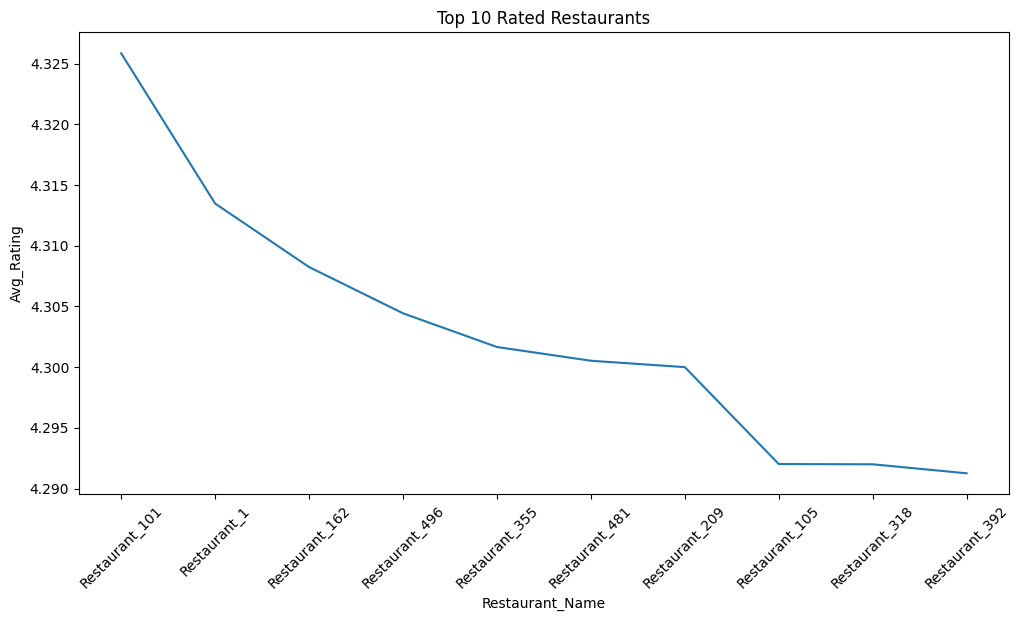

In [90]:
#Visualizations 1. Top Rated Restaurants
plt.figure(figsize=(12,6))

sns.lineplot(
    data=top_restaurants.sort_values(
        'Avg_Rating',
        ascending=False
    ).head(10),
    x='Restaurant_Name',
    y='Avg_Rating'
)

plt.xticks(rotation=45)
plt.title('Top 10 Rated Restaurants')
plt.show()

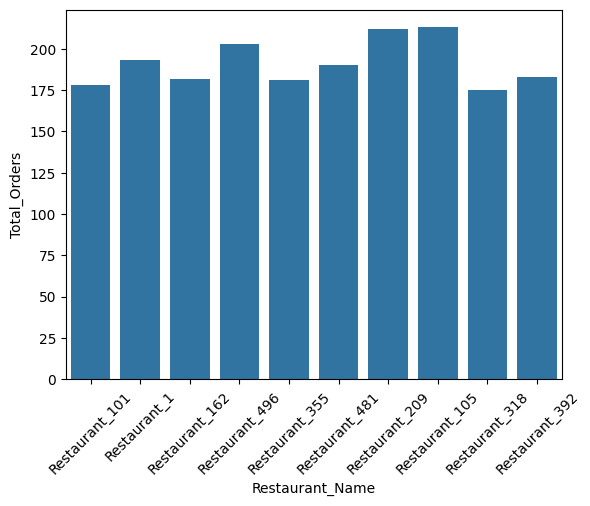

In [91]:
#2. Orders by Top Restaurants
sns.barplot(
    data=top_restaurants.sort_values(
        'Avg_Rating',
        ascending=False
    ).head(10),
    x='Restaurant_Name',
    y='Total_Orders'
)

plt.xticks(rotation=45)
plt.show()

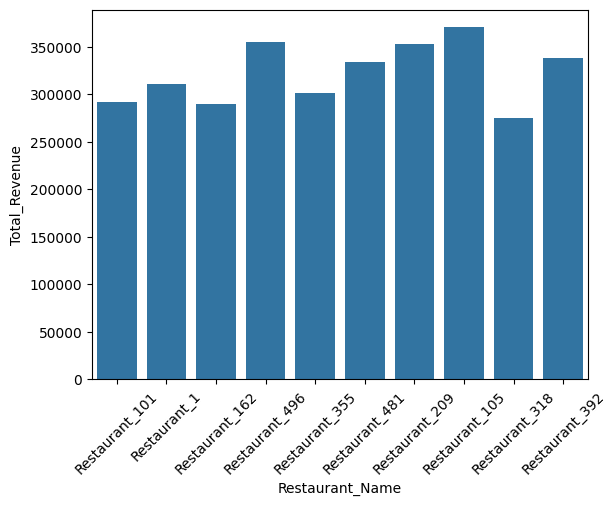

In [92]:
#3. Revenue by Top Restaurants
sns.barplot(
    data=top_restaurants.sort_values(
        'Avg_Rating',
        ascending=False
    ).head(10),
    x='Restaurant_Name',
    y='Total_Revenue'
)

plt.xticks(rotation=45)
plt.show()

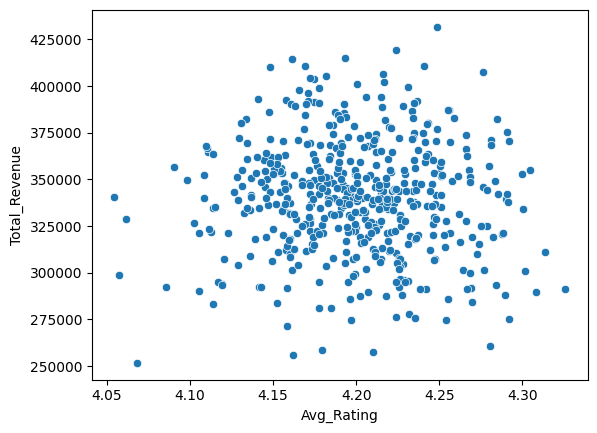

In [93]:
#4. Rating vs Revenue
sns.scatterplot(
    data=top_restaurants,
    x='Avg_Rating',
    y='Total_Revenue'
)

plt.show()

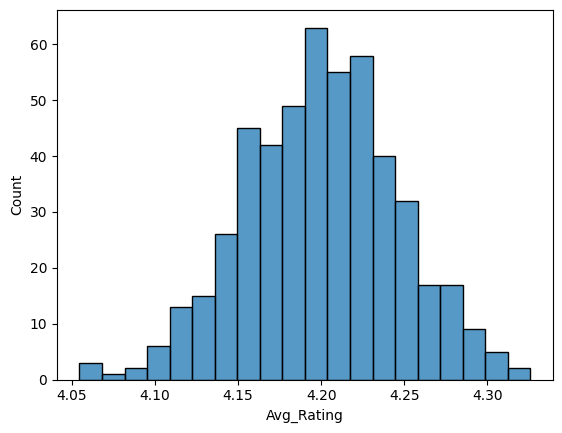

In [95]:
#5. Rating Distribution
sns.histplot(
    top_restaurants['Avg_Rating'],
    bins=20
)

plt.show()

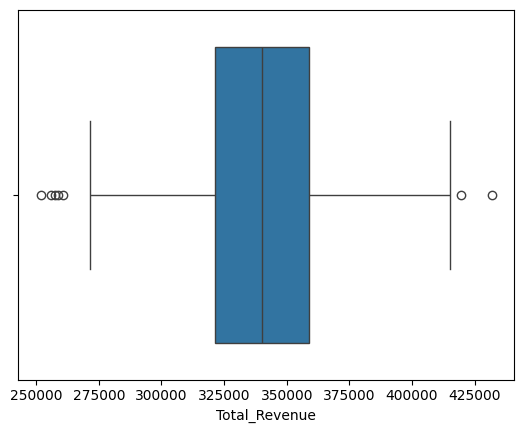

In [96]:
#6. Revenue Distribution
sns.boxplot(
    x=top_restaurants['Total_Revenue']
)

plt.show()

Professional Insights
Insight 1

Restaurant_101 achieved the highest average rating (4.326) among restaurants with significant order volume.

Insight 2

Highly rated restaurants generally maintain strong order counts, indicating customer satisfaction supports repeat business.

Insight 3

Restaurant_105 generated the highest revenue among the top-rated group, suggesting that high ratings can translate into stronger financial performance.

Insight 4

The rating differences among the top restaurants are very small (4.29–4.33), indicating strong competition among leading restaurants.

Task 11 – Cancellation Rate by Restaurant

In [97]:
cancel_summary = pd.crosstab(
    df['Restaurant_Name'],
    df['Order_Status']
)

cancel_summary['Cancellation_Rate'] = (
    cancel_summary['Cancelled'] /
    (cancel_summary['Cancelled'] + cancel_summary['Delivered'])
) * 100

cancel_summary = cancel_summary.reset_index()

cancel_summary = cancel_summary[
    (cancel_summary['Cancelled'] + cancel_summary['Delivered']) >= 100
]

cancel_summary.sort_values(
    'Cancellation_Rate',
    ascending=False
).head(10)

Order_Status,Restaurant_Name,Cancelled,Delivered,Cancellation_Rate
324,Restaurant_391,43,153,21.938776
323,Restaurant_390,44,157,21.890547
419,Restaurant_477,38,138,21.590909
115,Restaurant_202,44,160,21.568627
304,Restaurant_373,41,150,21.465969
363,Restaurant_426,45,167,21.226415
221,Restaurant_299,41,153,21.134021
395,Restaurant_455,38,142,21.111111
16,Restaurant_113,43,162,20.975610
148,Restaurant_232,37,140,20.903955


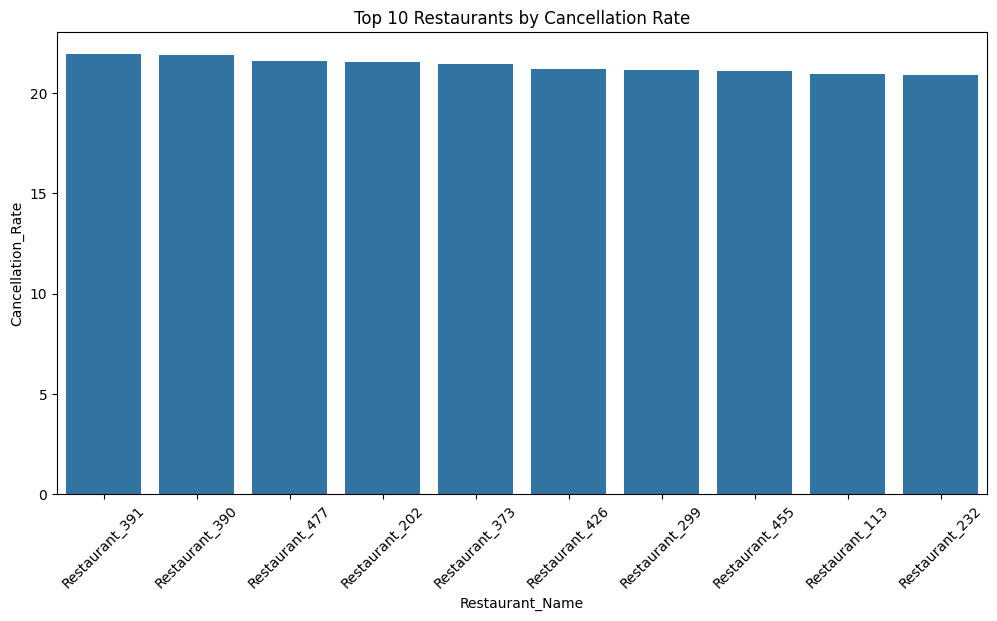

In [98]:
#Visualizations 1. Top 10 Cancellation Rates
plt.figure(figsize=(12,6))

sns.barplot(
    data=cancel_summary.sort_values(
        'Cancellation_Rate',
        ascending=False
    ).head(10),
    x='Restaurant_Name',
    y='Cancellation_Rate'
)

plt.xticks(rotation=45)
plt.title('Top 10 Restaurants by Cancellation Rate')
plt.show()

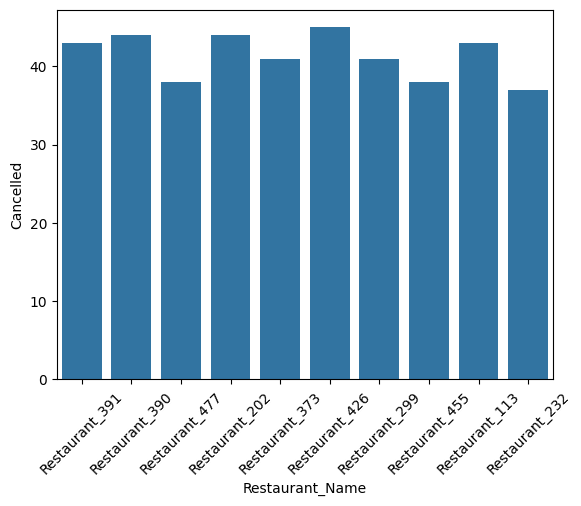

In [99]:
#2. Cancelled Orders
sns.barplot(
    data=cancel_summary.sort_values(
        'Cancellation_Rate',
        ascending=False
    ).head(10),
    x='Restaurant_Name',
    y='Cancelled'
)

plt.xticks(rotation=45)
plt.show()

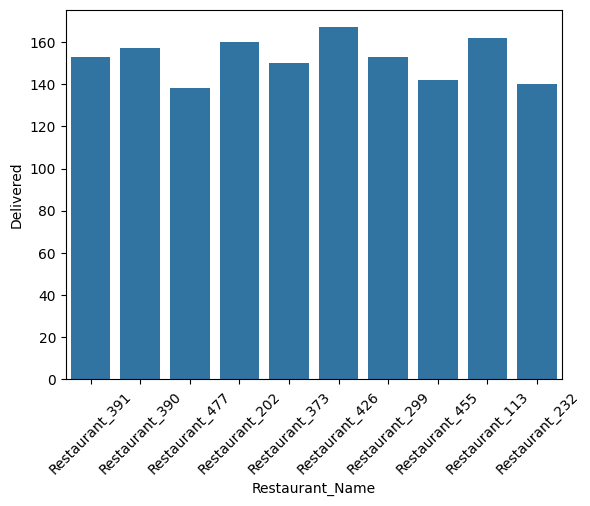

In [100]:
#3. Delivered Orders
sns.barplot(
    data=cancel_summary.sort_values(
        'Cancellation_Rate',
        ascending=False
    ).head(10),
    x='Restaurant_Name',
    y='Delivered'
)

plt.xticks(rotation=45)
plt.show()

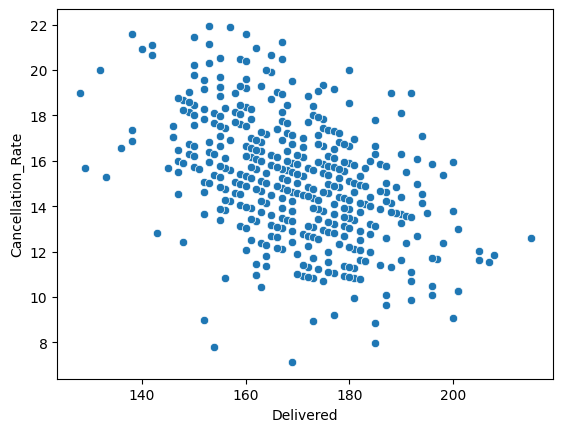

In [101]:
#4. Cancellation vs Delivery
sns.scatterplot(
    data=cancel_summary,
    x='Delivered',
    y='Cancellation_Rate'
)

plt.show()

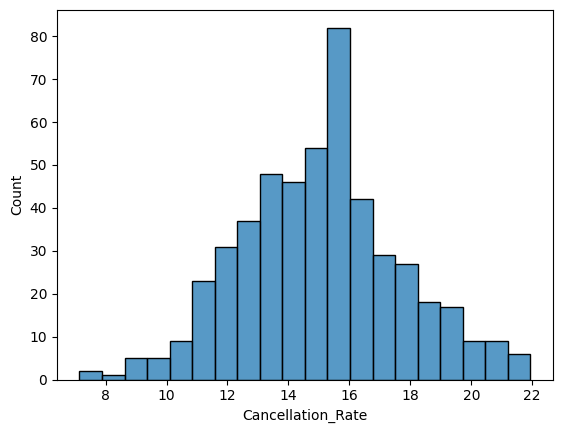

In [102]:
#5. Cancellation Rate Distribution
sns.histplot(
    cancel_summary['Cancellation_Rate'],
    bins=20
)

plt.show()

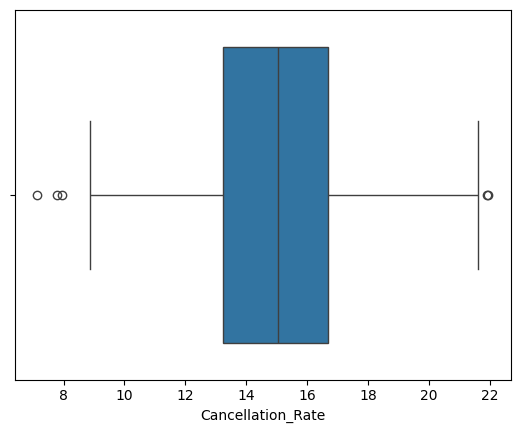

In [103]:
#6. Boxplot
sns.boxplot(
    x=cancel_summary['Cancellation_Rate']
)

plt.show()

Professional Insights
Insight 1

Restaurant_391 has the highest cancellation rate at 21.94%, indicating a significant proportion of orders fail to reach completion.

Insight 2

Several restaurants show cancellation rates above 21%, suggesting recurring operational issues rather than isolated incidents.

Insight 3

High cancellation rates are observed despite relatively strong delivery counts, indicating demand exists but fulfillment consistency may be lacking.

Insight 4

A small group of restaurants contributes disproportionately to cancellation risk and should be monitored closely.

Task 12: Cuisine Performance Analysis

In [15]:
cuisine_summary = df.groupby('Cuisine_Type').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Order_Value=('Final_Amount','mean'),
    Avg_Rating=('Restaurant_Rating','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).reset_index()

cuisine_summary.sort_values(
    by='Total_Revenue',
    ascending=False
)

,Cuisine_Type,Total_Orders,Total_Revenue,Avg_Order_Value,Avg_Rating,Avg_Profit_Margin
2,Indian,33570,57427079.0,1710.666637,4.200077,0.149503
4,Mexican,16602,28339695.0,1707.004879,4.195519,0.151118
1,Chinese,16651,28327539.0,1701.251516,4.190583,0.149340
0,Arabian,16658,28050563.0,1683.909413,4.202251,0.151138
3,Italian,16519,27949630.0,1691.968642,4.210231,0.151595


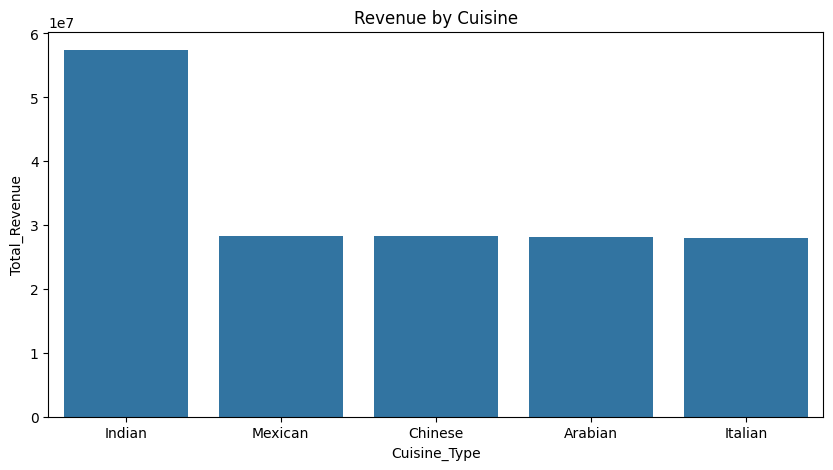

In [5]:
#Visualization 1: Revenue by Cuisine
plt.figure(figsize=(10,5))
sns.barplot(
    data=cuisine_summary.sort_values('Total_Revenue', ascending=False),
    x='Cuisine_Type',
    y='Total_Revenue'
)
plt.title('Revenue by Cuisine')
plt.show()

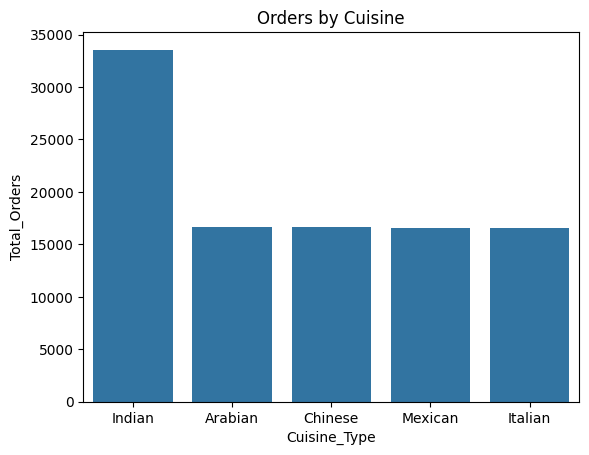

In [16]:
#Visualization 2: Orders by Cuisine
sns.barplot(
    data=cuisine_summary.sort_values('Total_Orders', ascending=False),
    x='Cuisine_Type',
    y='Total_Orders'
)
plt.title('Orders by Cuisine')
plt.show()

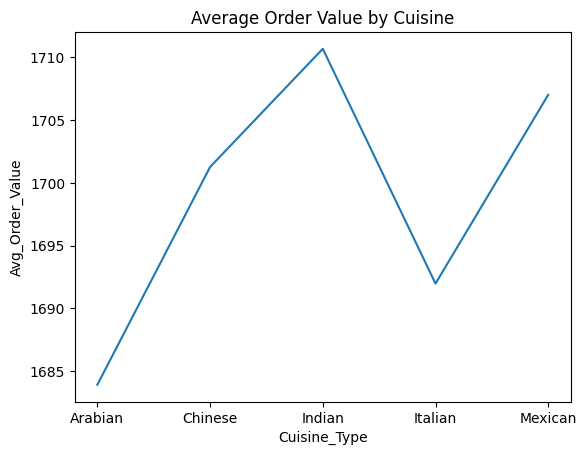

In [14]:
#Visualization 3: Average Order Value
sns.lineplot(
    data=cuisine_summary,
    x='Cuisine_Type',
    y='Avg_Order_Value'
)
plt.title('Average Order Value by Cuisine')
plt.show()

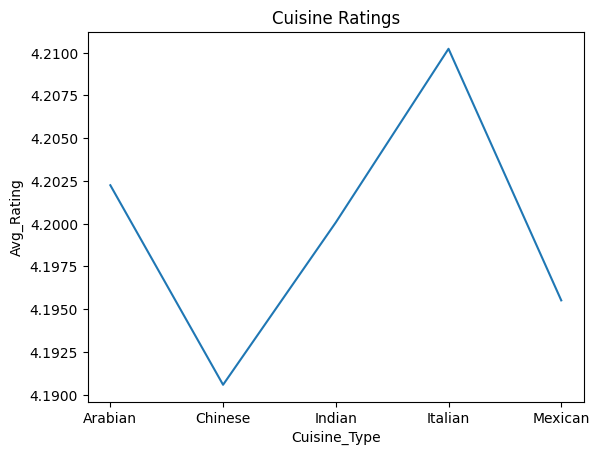

In [13]:
#Visualization 4: Average Rating
sns.lineplot(
    data=cuisine_summary,
    x='Cuisine_Type',
    y='Avg_Rating'
)
plt.title('Cuisine Ratings')
plt.show()

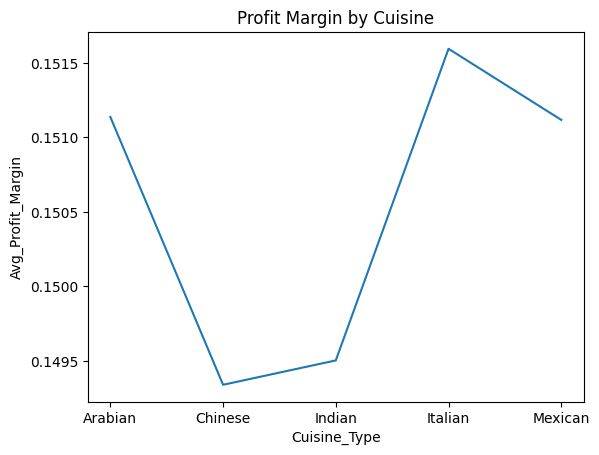

In [23]:
#Visualization 5: Profit Margin
sns.lineplot(
    data=cuisine_summary,
    x='Cuisine_Type',
    y='Avg_Profit_Margin'
)
plt.title('Profit Margin by Cuisine')
plt.show()

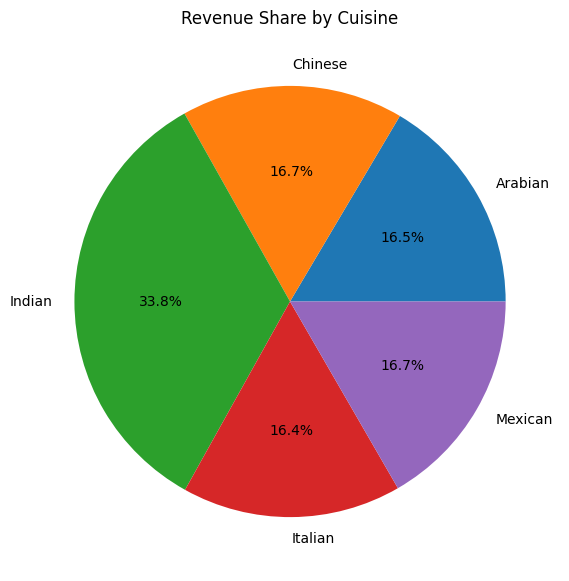

In [12]:
#Visualization 6: Revenue Share
cuisine_summary.set_index('Cuisine_Type')['Total_Revenue'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)
plt.ylabel('')
plt.title('Revenue Share by Cuisine')
plt.show()

Professional Insights
Insight 1

Indian cuisine dominates the platform, generating ₹57.43 million in revenue and 33,570 orders, which is approximately double the revenue of any other cuisine category.

Insight 2

Revenue among Mexican, Chinese, Arabian, and Italian cuisines is remarkably balanced, suggesting diversified customer preferences beyond Indian food.

Insight 3

Italian cuisine receives the highest average restaurant rating (4.21), indicating strong customer satisfaction and service quality.

Insight 4

Italian cuisine also delivers the highest profit margin (15.16%), making it one of the most attractive categories from both customer satisfaction and profitability perspectives.

Task 13: Peak Hour Demand Analysis

In [40]:
df['Peak_Hour'].value_counts(dropna=False)

,count
Peak_Hour,
False,66547
True,33453


In [41]:
peak_summary = df.groupby('Peak_Hour').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Order_Value=('Final_Amount','mean'),
    Avg_Delivery_Time=('Delivery_Time_Min','mean'),
    Avg_Delivery_Rating=('Delivery_Rating_Filled','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).reset_index()

peak_summary

,Peak_Hour,Total_Orders,Total_Revenue,Avg_Order_Value,Avg_Delivery_Time,Avg_Delivery_Rating,Avg_Profit_Margin
0,False,66547,113172200.0,1700.635641,125.129938,2.991179,0.150518
1,True,33453,56922306.0,1701.560578,124.687801,2.996413,0.150052


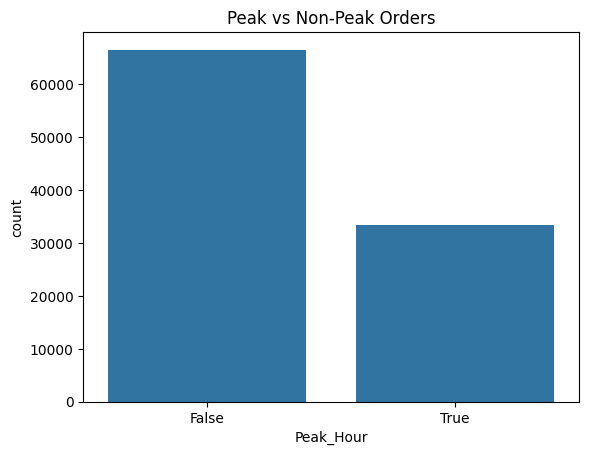

In [44]:
#Visualizations 1. Orders Distribution
sns.countplot(data=df, x='Peak_Hour')
plt.title('Peak vs Non-Peak Orders')
plt.show()

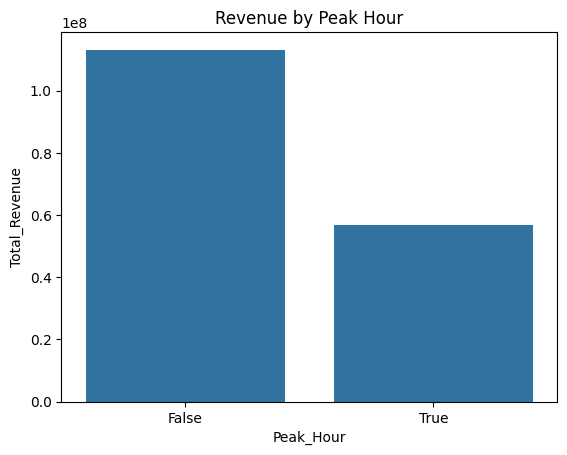

In [45]:
#2. Revenue Comparison
sns.barplot(
    data=peak_summary,
    x='Peak_Hour',
    y='Total_Revenue'
)
plt.title('Revenue by Peak Hour')
plt.show()

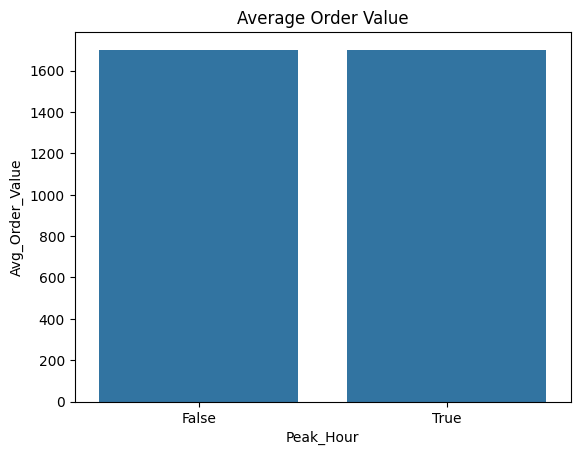

In [48]:
#3. Average Order Value
sns.barplot(
    data=peak_summary,
    x='Peak_Hour',
    y='Avg_Order_Value'
)
plt.title('Average Order Value')
plt.show()

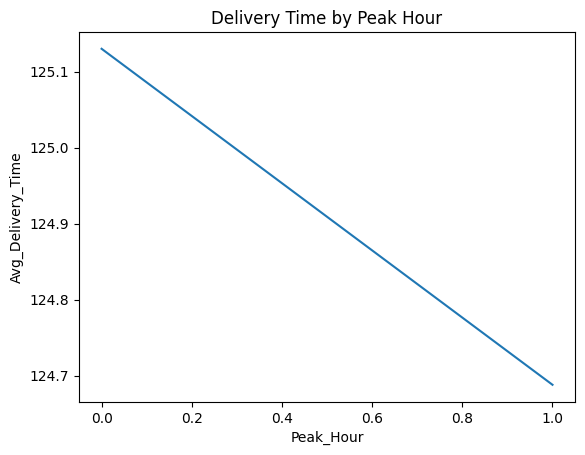

In [50]:
#4. Delivery Time
sns.lineplot(
    data=peak_summary,
    x='Peak_Hour',
    y='Avg_Delivery_Time'
)
plt.title('Delivery Time by Peak Hour')
plt.show()

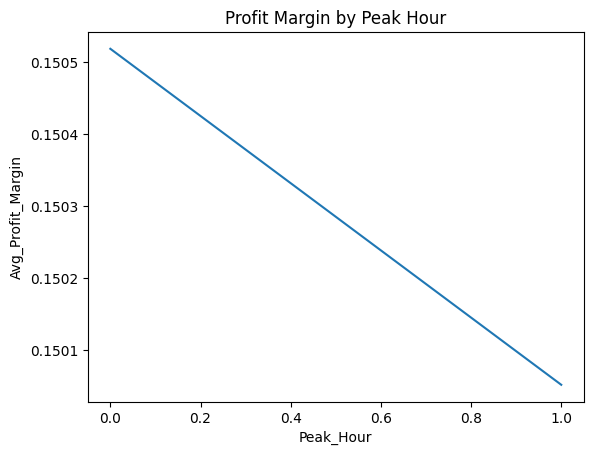

In [52]:
#6. Profit Margin
sns.lineplot(
    data=peak_summary,
    x='Peak_Hour',
    y='Avg_Profit_Margin'
)
plt.title('Profit Margin by Peak Hour')
plt.show()

Professional Insights
Insight 1

Peak hours account for 33.45% of total orders and generate ₹56.92 million in revenue, making them a critical revenue window despite representing only one-third of total demand.

Insight 2

Average order values remain virtually identical:

Non-Peak = ₹1700.64
Peak = ₹1701.56

This suggests customers do not spend significantly more during peak periods.

Insight 3

Delivery times remain stable during peak demand:

Peak = 124.69 min
Non-Peak = 125.13 min

This indicates effective delivery capacity management.

Insight 4

Customer ratings and profit margins remain nearly unchanged across peak and non-peak periods, demonstrating operational consistency.

Task 15: Order Status & Cancellation Analysis

In [24]:
status_summary = df.groupby('Order_Status').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Order_Value=('Final_Amount','mean')
).reset_index()

status_summary

,Order_Status,Total_Orders,Total_Revenue,Avg_Order_Value
0,Cancelled,15036,25493938.0,1695.526603
1,Delivered,84964,144600568.0,1701.903959


In [27]:
df['Cancellation_Reason'].value_counts()
#Limitation with reason as 9031 orders only has reason available among 15036 cancelled orders

,count
Cancellation_Reason,
Late Delivery,3059
Customer Cancelled,2993
Restaurant Issue,2979


In [28]:
cancel_rate = (
    df[df['Order_Status']=='Cancelled'].shape[0]
    /
    df.shape[0]
) * 100

print(cancel_rate)

15.036


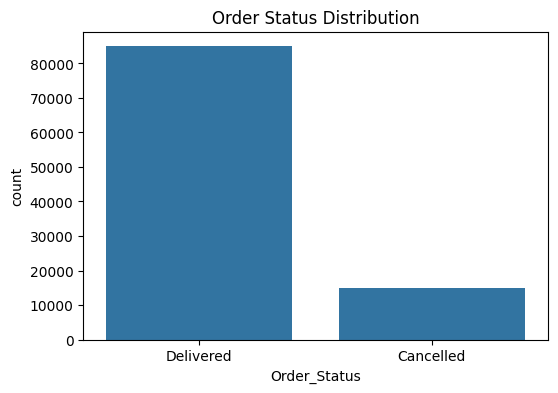

In [31]:
#Visualization 1: Order Status Distribution
plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='Order_Status'
    )
plt.title('Order Status Distribution')
plt.show()

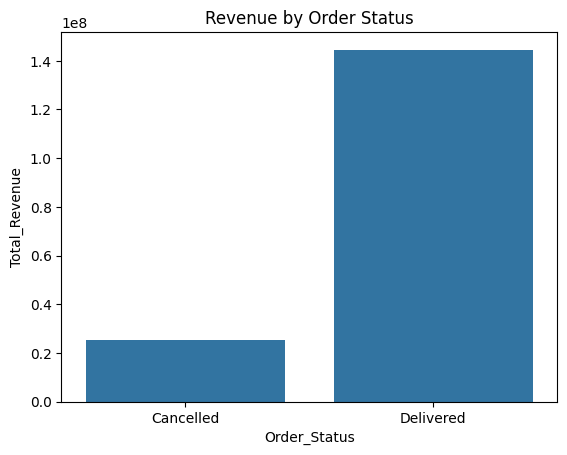

In [33]:
#Visualization 2: Revenue by Status
sns.barplot(
    data=status_summary,
    x='Order_Status',
    y='Total_Revenue'
)
plt.title('Revenue by Order Status')
plt.show()

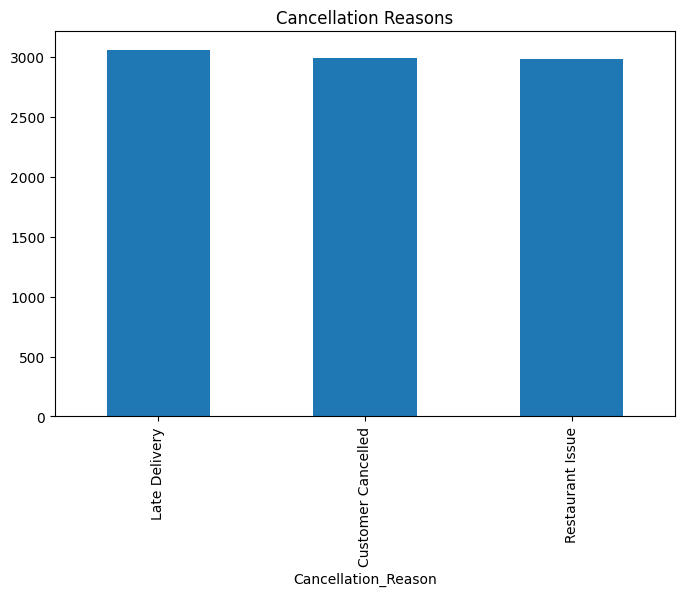

In [34]:
#Visualization 3: Cancellation Reasons
cancel_reason = (
    df['Cancellation_Reason']
    .value_counts()
)

cancel_reason.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Cancellation Reasons')
plt.show()

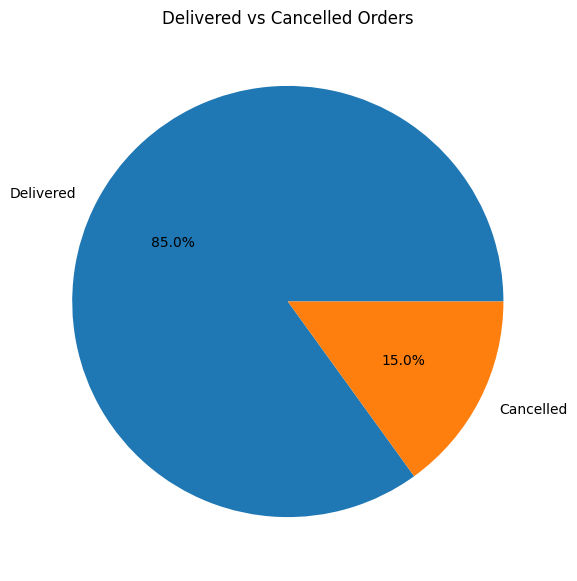

In [35]:
#Visualization 4: Status Percentage
df['Order_Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.ylabel('')
plt.title('Delivered vs Cancelled Orders')
plt.show()

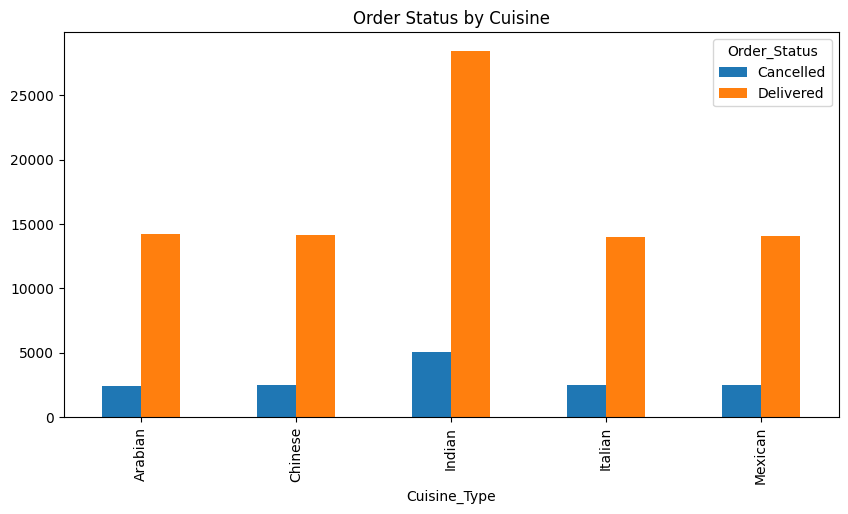

In [36]:
#Visualization 5: Cancellation by Cuisine
cancel_cuisine = pd.crosstab(
    df['Cuisine_Type'],
    df['Order_Status']
)

cancel_cuisine.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Order Status by Cuisine')
plt.show()

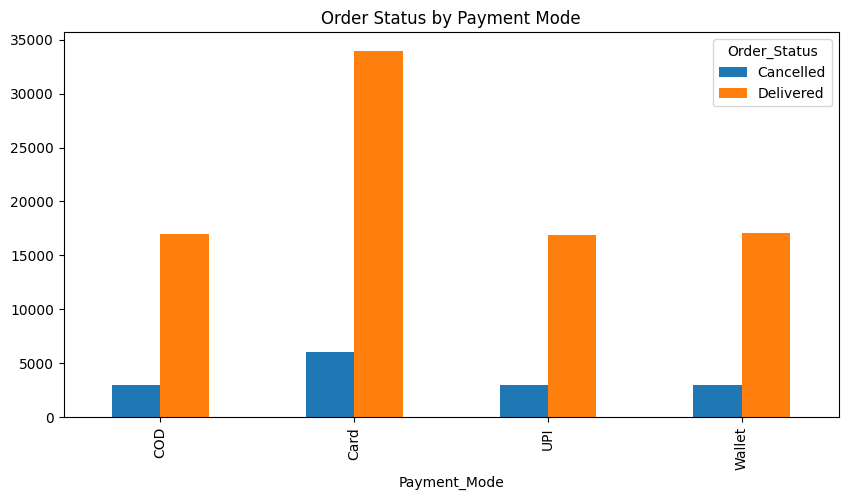

In [38]:
#Visualization 6: Cancellation by Payment Mode
cancel_payment = pd.crosstab(
    df['Payment_Mode'],
    df['Order_Status']
)

cancel_payment.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Order Status by Payment Mode')
plt.show()

Professional Insights
Insight 1

The platform maintains a strong fulfillment rate, with 84.96% of orders successfully delivered and a cancellation rate of 15.04%.

Insight 2

Late Delivery is the leading recorded cancellation reason (3,059 cases), making delivery efficiency a major operational improvement opportunity.

Insight 3

Customer-initiated cancellations (2,993) are nearly equal to late-delivery cancellations, suggesting expectations management and communication may be as important as logistics.

Insight 4

Restaurant-related issues account for 2,979 cancellations, indicating that restaurant operations contribute significantly to order failures.

Task 6: City Performance Analysis

In [39]:
city_summary = df.groupby('City').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Order_Value=('Final_Amount','mean'),
    Avg_Delivery_Time=('Delivery_Time_Min','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).reset_index()

city_summary.sort_values(
    by='Total_Revenue',
    ascending=False
)

,City,Total_Orders,Total_Revenue,Avg_Order_Value,Avg_Delivery_Time,Avg_Profit_Margin
3,Hyderabad,33610,57034000.0,1696.935436,125.070872,0.150303
0,Bangalore,16732,28651047.0,1712.350406,124.373297,0.150222
2,Delhi,16695,28257765.0,1692.588500,124.896376,0.150337
1,Chennai,16470,28139875.0,1708.553430,124.549423,0.148653
4,Mumbai,16493,28011819.0,1698.406536,125.937246,0.152357


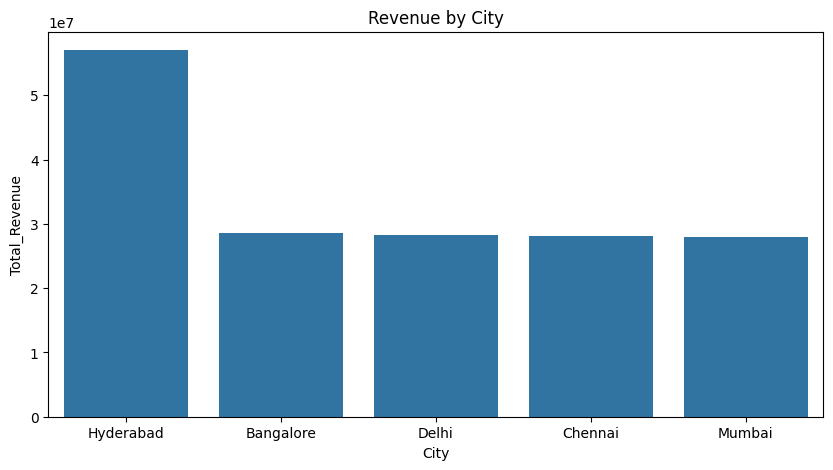

In [40]:
#Visualization 1: Revenue by City
plt.figure(figsize=(10,5))
sns.barplot(
    data=city_summary.sort_values('Total_Revenue', ascending=False),
    x='City',
    y='Total_Revenue'
)
plt.title('Revenue by City')
plt.show()

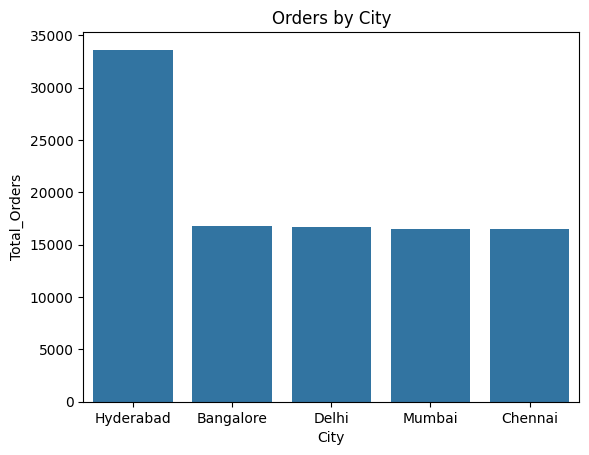

In [45]:
#Visualization 2: Orders by City
sns.barplot(
    data=city_summary.sort_values('Total_Orders', ascending=False),
    x='City',
    y='Total_Orders'
)
plt.title('Orders by City')
plt.show()

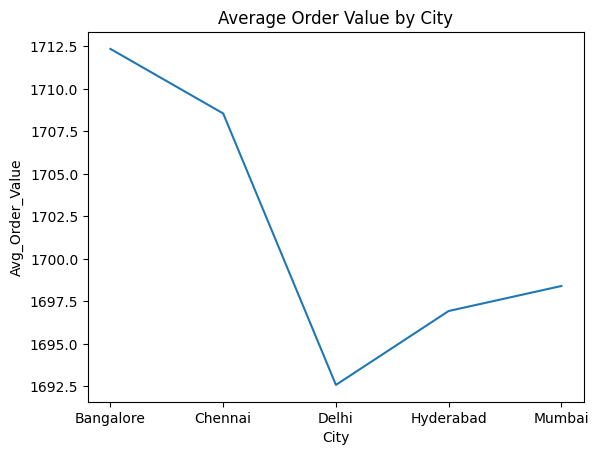

In [43]:
#Visualization 3: Average Order Value
sns.lineplot(
    data=city_summary,
    x='City',
    y='Avg_Order_Value'
)
plt.title('Average Order Value by City')
plt.show()

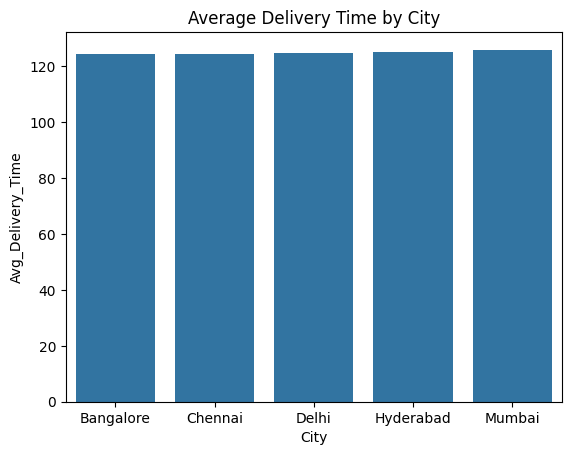

In [52]:
#Visualization 4: Delivery Time
sns.barplot(
    data=city_summary,
    x='City',
    y='Avg_Delivery_Time'
)
plt.title('Average Delivery Time by City')
plt.show()

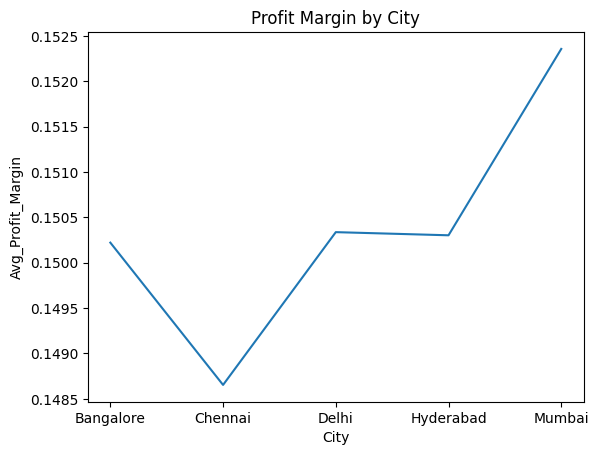

In [50]:
#Visualization 5: Profit Margin
sns.lineplot(
    data=city_summary,
    x='City',
    y='Avg_Profit_Margin'
)
plt.title('Profit Margin by City')
plt.show()

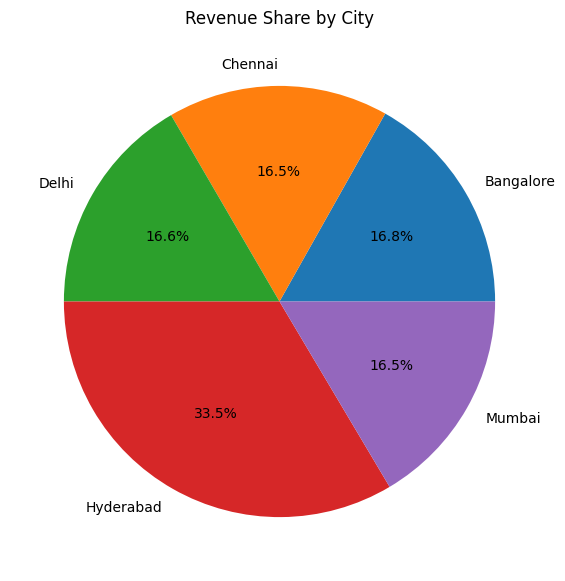

In [51]:
#Visualization 6: Revenue Share
city_summary.set_index('City')['Total_Revenue'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)
plt.ylabel('')
plt.title('Revenue Share by City')
plt.show()

Professional Insights
Insight 1

Hyderabad is the dominant market, generating ₹57.03 million in revenue and 33,610 orders, nearly double the volume of every other city.

Insight 2

Bangalore records the highest average order value (₹1712.35), indicating stronger customer spending per transaction.

Insight 3

Mumbai achieves the highest profit margin (15.24%), making it the most profitable city despite not being the highest-revenue market.

Insight 4

Delivery times are remarkably consistent across all cities (124–126 minutes), indicating standardized operational performance.

Task 14: Payment Mode Analysis

In [53]:
payment_summary = df.groupby('Payment_Mode').agg(
    Total_Orders=('Order_ID','count'),
    Total_Revenue=('Final_Amount','sum'),
    Avg_Order_Value=('Final_Amount','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).reset_index()

payment_summary.sort_values(
    by='Total_Revenue',
    ascending=False
)

,Payment_Mode,Total_Orders,Total_Revenue,Avg_Order_Value,Avg_Profit_Margin
1,Card,40005,67783052.0,1694.364504,0.149896
0,COD,19977,34232164.0,1713.578816,0.149822
3,Wallet,20086,34056771.0,1695.547695,0.151553
2,UPI,19932,34022519.0,1706.929510,0.150639


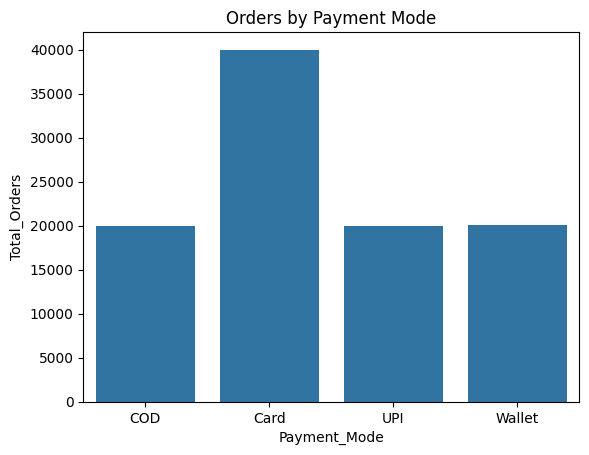

In [54]:
#Visualization 1: Orders by Payment Mode
sns.barplot(
    data=payment_summary,
    x='Payment_Mode',
    y='Total_Orders'
)
plt.title('Orders by Payment Mode')
plt.show()

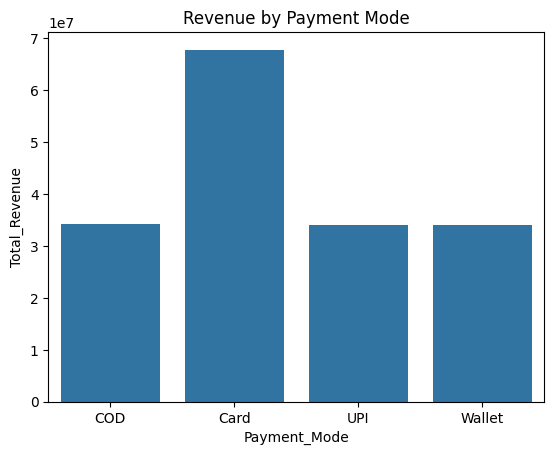

In [55]:
#Visualization 2: Revenue by Payment Mode
sns.barplot(
    data=payment_summary,
    x='Payment_Mode',
    y='Total_Revenue'
)
plt.title('Revenue by Payment Mode')
plt.show()

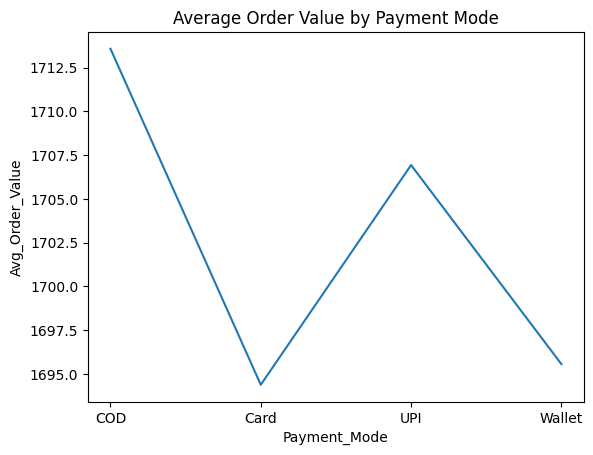

In [56]:
#Visualization 3: Average Order Value
sns.lineplot(
    data=payment_summary,
    x='Payment_Mode',
    y='Avg_Order_Value'
)
plt.title('Average Order Value by Payment Mode')
plt.show()

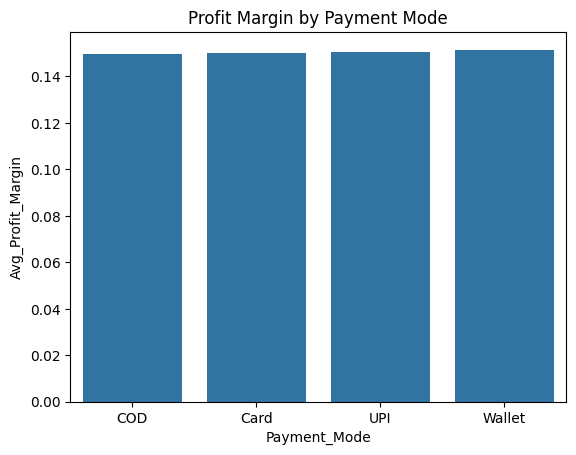

In [59]:
#Visualization 4: Profit Margin
sns.barplot(
    data=payment_summary,
    x='Payment_Mode',
    y='Avg_Profit_Margin'
)
plt.title('Profit Margin by Payment Mode')
plt.show()

Text(0.5, 1.0, 'Revenue Share by Payment Mode')

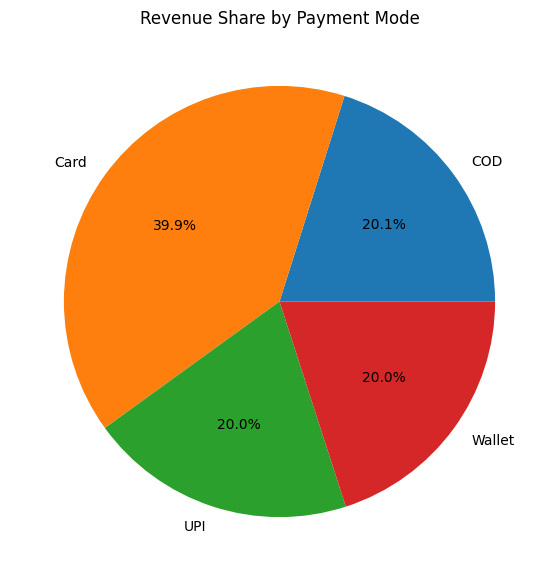

In [60]:
#Visualization 5: Revenue Share
payment_summary.set_index('Payment_Mode')['Total_Revenue'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)
plt.ylabel('')
plt.title('Revenue Share by Payment Mode')

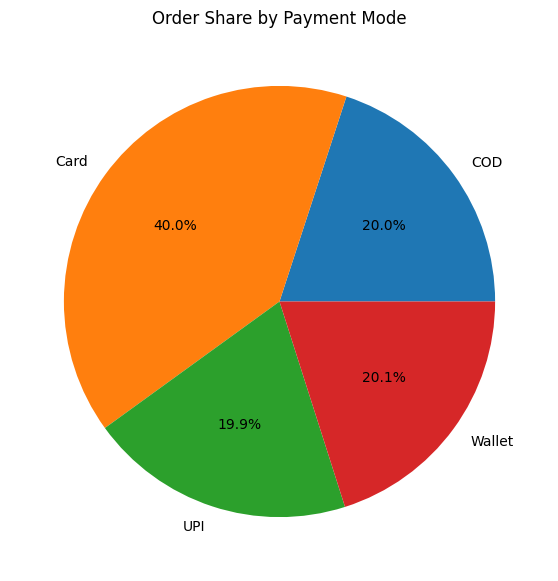

In [61]:
#Visualization 6: Orders Share
payment_summary.set_index('Payment_Mode')['Total_Orders'].plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.ylabel('')
plt.title('Order Share by Payment Mode')
plt.show()

Professional Insights
Insight 1

Card payments dominate the platform, accounting for 40,005 orders and ₹67.78 million in revenue, representing roughly 40% of total transactions.

Insight 2

COD customers have the highest average order value (₹1713.58), suggesting that customers choosing cash-on-delivery tend to place slightly larger orders.

Insight 3

Wallet payments generate the highest average profit margin (15.16%), making them the most profitable payment channel.

Insight 4

Revenue among COD, Wallet, and UPI is relatively balanced, indicating healthy diversification across payment methods.